# ⚖️ Legal Document Assistant
## Router Architecture using LangGraph + Groq

---

### 🏗️ Architecture: Router Pattern (Intent-Based Routing)

```
                    Router
              /      |       |      \
         Contract   IP Law  Employment  Compliance
           Agent   Agent     Agent       Agent
```

**Flow:**
```
User legal query
      ↓
  Router classifies legal domain
      ↓
  ONE specialist legal agent handles it
      ↓
  Legal guidance returned → END
```

**What each agent does:**
| Agent | Legal Domain | Example Query |
|-------|-------------|---------------|
| Router | Classifies legal intent | (all queries) |
| Contract Agent | NDAs, SLAs, vendor agreements, clause review | "Is this NDA clause enforceable?" |
| IP Agent | Patents, trademarks, copyrights, trade secrets | "Can I patent my software algorithm?" |
| Employment Agent | Hiring, termination, discrimination, wages | "What severance am I entitled to?" |
| Compliance Agent | GDPR, HIPAA, SOX, regulatory requirements | "Do we need a DPA with this vendor?" |
| General Agent | Cross-domain or ambiguous legal questions | Fallback for unclear queries |

---

### 🆚 HR Copilot (Project 3) vs Legal Assistant (Project 4)

| Aspect | HR Copilot (P3) | Legal Assistant (P4) |
|--------|----------------|----------------------|
| Domain | HR policies | Legal domains |
| Knowledge base | Company policy strings | Legal principles + statutes |
| Risk level | Low (policy info) | HIGH (legal advice) |
| Disclaimer needed | No | ⚠️ YES — always |
| Ambiguity | Clear intents | Often cross-domain |
| Special feature | Confidence threshold | Multi-domain detection |

**Same Router Architecture — but legal domain adds complexity:**
- Legal queries are often cross-domain (employment + contract, IP + compliance)
- Must ALWAYS disclaim AI-generated legal content
- Higher stakes = more careful prompt engineering

---

⚠️ **IMPORTANT DISCLAIMER**  
This tool provides general legal information for educational purposes only.  
It is NOT a substitute for advice from a qualified attorney.  
Always consult a licensed lawyer for actual legal decisions.

### Step 0: Loading Environment & Liabraries

In [1]:
from dotenv import load_dotenv
load_dotenv()
import os

In [2]:
# pydantic: For structured data validation
from pydantic import BaseModel, Field

# LangChain components for prompts and parsing
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.output_parsers import PydanticOutputParser

# LangChain message types
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage

# LangChain runnable
from langchain_core.runnables import RunnablePassthrough

# LangGraph
from langgraph.graph import StateGraph, END

c:\Users\HP\anaconda3\envs\fresh_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 1: Loading/Initializing LLM

In [3]:
from langchain_groq import ChatGroq

# Groq automatically reads GROQ_API_KEY from environment variables

model = ChatGroq(
    model="openai/gpt-oss-120b",   # or llama-3.3-70b-versatile
    temperature=0.7
)

llm = model

In [4]:
# ---- TEST ----
try:
    response = llm.invoke("Say hello in one sentence.")
    print("✅ Groq LLM initialized successfully")
    print("Response:", response.content)

except Exception as e:
    print("❌ Groq LLM initialization failed")
    print(e)

✅ Groq LLM initialized successfully
Response: Hello, nice to meet you!


## 📋 Step 2 — Shared State Definition

**Comparing all 3 Router/Supervisor state designs across our projects:**

```
Project 1 (Supervisor — Finance):     Project 3 (Router — HR):
  company_name                           query
  financial_data    ← Data Agent         route
  news_data         ← News Agent         answer
  investment_memo   ← Writer Agent       confidence
  next_agent        ← Supervisor         messages
  messages

Project 4 (Router — Legal):    ← THIS PROJECT
  query                         same as P3 +
  legal_domain                  legal-specific fields:
  answer
  confidence
  is_cross_domain    ← NEW: legal queries often span multiple domains
  secondary_domains  ← NEW: track ALL relevant domains, not just primary
  messages
```

The two new fields (`is_cross_domain`, `secondary_domains`) handle a real problem:
an employment termination query often ALSO involves contract law.  
Tracking this lets us give richer, more complete answers.

In [5]:
from typing import TypedDict, Optional, List


class LegalState(TypedDict):
    """
    Shared state for the Legal Document Assistant routing pipeline.

    Extends the basic Router state (from HR Copilot) with
    legal-specific fields to handle cross-domain queries.

    Legal queries are uniquely challenging because:
    - "Can I fire someone for posting on social media?" → Employment + Compliance
    - "Does my NDA cover my open-source contribution?" → Contract + IP
    - "We're collecting EU user data, what do we need?" → Compliance + Contract
    Tracking secondary domains helps the specialist agent give fuller answers.
    """

    # --- Input ---
    # The user's legal question in plain English
    query: str

    # --- Router Output ---
    # Primary legal domain assigned by the router
    # Values: "contract" | "ip" | "employment" | "compliance" | "general"
    legal_domain: str

    # Confidence score (0.0–1.0) for the routing decision
    # < 0.6 → might trigger fallback or ask for clarification
    confidence: Optional[float]

    # True if the query touches multiple legal domains
    # e.g., "employment termination clause in a contract" → True
    is_cross_domain: Optional[bool]

    # List of additional domains relevant to the query (besides the primary)
    # e.g., ["employment", "compliance"] if primary is "contract"
    secondary_domains: Optional[List[str]]

    # --- Agent Output ---
    # The legal guidance produced by the selected specialist agent
    answer: Optional[str]

    # Running log of the request lifecycle
    messages: list


print("✅ LegalState defined!")
print("   Fields:", list(LegalState.__annotations__.keys()))
print()
print("   New vs HR Copilot state:")
print("   + is_cross_domain  → detects queries spanning multiple legal areas")
print("   + secondary_domains → tracks all relevant domains for richer answers")

✅ LegalState defined!
   Fields: ['query', 'legal_domain', 'confidence', 'is_cross_domain', 'secondary_domains', 'answer', 'messages']

   New vs HR Copilot state:
   + is_cross_domain  → detects queries spanning multiple legal areas
   + secondary_domains → tracks all relevant domains for richer answers


## 🗺️ Step 3 — The Legal Router Agent

**Key upgrade from HR Router (Project 3):**  
The legal router detects MULTIPLE domains per query, not just one.

```
HR Router output:       Legal Router output:
{
  "route": "payroll"    "legal_domain": "employment",
  "confidence": 0.95    "confidence": 0.85,
}                       "is_cross_domain": true,
                        "secondary_domains": ["contract"],
                        "reason": "..."
                        }
```

This richer output lets the specialist agents acknowledge related domains in their answers.

In [9]:
import json
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage 


def legal_router(state: dict) -> dict:
    """
    The Legal Router: classifies query into a legal domain.

    Upgrade from HR Router:
    - Detects cross-domain queries (legal questions often span 2+ areas)
    - Returns secondary domains for richer specialist agent responses
    - Uses lower confidence threshold triggers for legal (higher stakes)

    Legal domains:
      "contract"    → NDAs, vendor agreements, SLAs, clause review
      "ip"          → patents, trademarks, copyrights, trade secrets
      "employment"  → hiring, termination, discrimination, wages, HR law
      "compliance"  → GDPR, HIPAA, SOX, industry regulations
      "general"     → cross-domain, ambiguous, or out-of-scope queries

    Args:
        state: LegalState — reads 'query'

    Returns:
        Dict updating 'legal_domain', 'confidence',
        'is_cross_domain', 'secondary_domains'
    """
    print("\n" + "="*60)
    print("⚖️  LEGAL ROUTER: Classifying legal query...")
    print("="*60)

    query = state["query"]
    print(f"   Query: \"{query}\"")

    # # Use a capable model for legal routing — domain classification here
    # # is genuinely harder than HR (more ambiguity, more cross-domain overlap)
    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0,      # Always 0 for routing — must be deterministic
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a legal domain classifier for a law firm's AI assistant.
Classify incoming legal queries into the correct legal domain.

Available legal domains:

1. "contract"
   → NDAs (non-disclosure agreements), vendor contracts, SLAs (service level agreements),
     partnership agreements, licensing agreements, contract clauses, breach of contract,
     contract review, indemnification, liability clauses, force majeure

2. "ip" (Intellectual Property)
   → patents (utility, design, provisional), trademarks, copyright,
     trade secrets, IP ownership, open source licensing, DMCA,
     IP infringement, software patents, brand protection

3. "employment"
   → hiring practices, employee termination, severance, non-compete clauses,
     workplace discrimination, harassment, wage disputes, labor law,
     employee benefits, wrongful termination, EEOC, FLSA, FMLA

4. "compliance"
   → GDPR (EU data privacy), HIPAA (healthcare data), SOX (financial reporting),
     CCPA (California privacy), PCI-DSS, AML, KYC, regulatory audits,
     data breach notification, DPA (data processing agreements), export controls

5. "general"
   → use when: query spans 3+ domains equally, truly ambiguous,
     or doesn't fit any specific legal area above

IMPORTANT: Legal queries often touch multiple domains.
Identify the PRIMARY domain AND any secondary domains.

Respond ONLY with valid JSON — no other text:
{
  "legal_domain": "<primary domain: contract|ip|employment|compliance|general>",
  "confidence": <float 0.0-1.0>,
  "is_cross_domain": <true|false>,
  "secondary_domains": ["<domain>", "<domain>"],
  "reason": "<one sentence explaining the primary domain choice>"
}

If not cross-domain, set secondary_domains to []"""),

        HumanMessage(content=f"Legal query: {query}")
    ]

    response = llm.invoke(messages)
    raw = response.content.strip()

    # Parse JSON — always wrap in try/except for production safety
    try:
        cleaned  = raw.replace("```json", "").replace("```", "").strip()
        decision = json.loads(cleaned)

        domain           = decision.get("legal_domain", "general")
        confidence       = decision.get("confidence", 0.0)
        is_cross         = decision.get("is_cross_domain", False)
        secondary        = decision.get("secondary_domains", [])
        reason           = decision.get("reason", "No reason provided")

    except json.JSONDecodeError:
        # If LLM fails to produce JSON, route to general (safest fallback)
        print(f"   ⚠️  JSON parse error. Raw: {raw[:100]}")
        domain, confidence, is_cross, secondary, reason = \
            "general", 0.0, False, [], "Parse error — defaulting to general"

    # Print routing decision for visibility
    print(f"   Primary domain  : {domain}")
    print(f"   Confidence      : {confidence:.0%}")
    print(f"   Cross-domain    : {'Yes' if is_cross else 'No'}"
          + (f" → also touches: {secondary}" if secondary else ""))
    print(f"   Reason          : {reason}")

    # LOW CONFIDENCE WARNING
    # In production: trigger human review or ask clarifying question
    if confidence < 0.6:
        print(f"   ⚠️  Low confidence ({confidence:.0%}) — routing to 'general' as safety measure")
        domain = "general"  # Override to general when uncertain

    return {
        "legal_domain":     domain,
        "confidence":       confidence,
        "is_cross_domain":  is_cross,
        "secondary_domains": secondary,
        "messages": state["messages"] + [
            {"role": "router",
             "content": (f"Routed to [{domain}] domain at {confidence:.0%} confidence. "
                         f"Cross-domain: {is_cross}. Secondary: {secondary}. Reason: {reason}")}
        ]
    }


print("✅ Legal Router defined!")
print()
print("   Upgrades over HR Router:")
print("   + Detects cross-domain queries")
print("   + Returns secondary_domains list")
print("   + Overrides to 'general' when confidence < 0.6")

✅ Legal Router defined!

   Upgrades over HR Router:
   + Detects cross-domain queries
   + Returns secondary_domains list
   + Overrides to 'general' when confidence < 0.6


## 📝 Step 4 — Contract Review Agent

**Role:** Analyze contract clauses, NDAs, vendor agreements, SLAs

**Key design:** This agent is given a **legal reasoning framework** in its system prompt —
not just a knowledge base, but an analytical process (identify → assess → recommend).
This produces more structured, lawyer-like answers.

In [10]:
# Contract Law knowledge base — core principles and common clause types
# In production: this would be a vector DB of actual contract templates + case law
CONTRACT_KB = """
=== CONTRACT LAW — KEY PRINCIPLES & COMMON CLAUSES ===

Contract Formation Requirements (US Law):
  - Offer: one party proposes specific terms
  - Acceptance: other party agrees to all material terms
  - Consideration: something of value exchanged by both parties
  - Capacity: both parties must be legally competent
  - Legality: contract purpose must be legal

NDA (Non-Disclosure Agreement) Key Elements:
  - Definition of confidential information (broad vs narrow — narrow is safer)
  - Duration: typically 2-5 years; perpetual NDAs raise enforceability concerns
  - Exclusions: info already public, independently developed, received from 3rd party
  - Permitted disclosures: legal requirements, court orders
  - Remedies: injunctive relief is standard (monetary damages hard to quantify)
  - One-way (unilateral) vs two-way (mutual) NDAs

Common Problematic Clauses:
  - Unlimited liability: cap liability at contract value or insurance amount
  - Unilateral termination without cause: ensure reciprocal rights
  - Automatic renewal (evergreen): always add notice period for cancellation
  - IP assignment: ensure it's limited to work product, not pre-existing IP
  - Indemnification: mutual indemnification preferred over one-sided
  - Choice of law: be cautious of unfavorable jurisdictions
  - Non-compete: scope, duration, geography must be reasonable to be enforceable

SLA (Service Level Agreement) Key Terms:
  - Uptime guarantees: 99.9% = ~8.7 hrs downtime/year; 99.99% = ~52 mins/year
  - Measurement windows: monthly vs annual SLA calculation matters significantly
  - Remedies: service credits are most common (typically 5-30% of monthly fee)
  - Exclusions: scheduled maintenance, force majeure, customer-caused outages
  - Escalation procedures and response time commitments

Force Majeure:
  - Excuses performance for extraordinary events (pandemic, war, natural disaster)
  - Must be unforeseeable AND beyond reasonable control
  - Should define covered events specifically, not use vague catch-all language
  - Typically requires notice within 30 days of the triggering event

Breach & Remedies:
  - Material breach: significant failure, entitles other party to terminate
  - Minor breach: entitles damages but contract continues
  - Cure period: typically 30 days' notice before termination for breach
  - Liquidated damages: pre-agreed damages must be reasonable estimate (not penalty)
"""


def contract_agent(state: dict) -> dict:
    """
    Specialist Agent: Contract Review
    Handles: NDAs, vendor contracts, SLAs, clause analysis, breach questions

    Uses a structured analytical framework:
    Identify issue → Assess risk → Recommend action
    """
    print("\n" + "="*60)
    print("📝 CONTRACT AGENT: Analyzing contract query...")
    print("="*60)

    query            = state["query"]
    is_cross         = state.get("is_cross_domain", False)
    secondary        = state.get("secondary_domains", [])

    print(f"   Query       : \"{query}\"")
    print(f"   Cross-domain: {is_cross} {f'| Also touches: {secondary}' if secondary else ''}")

    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.1,    # Low — legal analysis must be precise and consistent
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    # Build a cross-domain note if this query touches other legal areas
    # This ensures the specialist agent doesn't ignore relevant dimensions
    cross_domain_note = ""
    if is_cross and secondary:
        cross_domain_note = f"""
NOTE: This query also touches these legal areas: {', '.join(secondary)}.
Please acknowledge these dimensions in your response and advise the user
to also consult specialists in those areas if needed."""

    messages = [
        SystemMessage(content=f"""You are a Contract Law specialist at a corporate law firm.
You review contracts, analyze clauses, identify risks, and provide actionable guidance.

YOUR ANALYTICAL FRAMEWORK — always structure answers as:
1. **Issue Identified**: What is the core legal question?
2. **Legal Analysis**: Relevant principles and how they apply
3. **Risk Assessment**: Low / Medium / High — with specific risks named
4. **Recommendations**: Concrete steps the user should take
5. **Attorney Note**: When to escalate to a human attorney

RULES:
- Base answers on the contract law knowledge base below
- Be specific — name exact clauses, typical durations, standard industry terms
- Always include a risk level assessment
- NEVER give a definitive legal opinion — you provide guidance, not legal advice
- End every answer with the standard disclaimer
{cross_domain_note}

CONTRACT LAW KNOWLEDGE BASE:
{CONTRACT_KB}"""),

        HumanMessage(content=query)
    ]

    response = llm.invoke(messages)
    print("   ✅ Contract Agent responded!")

    return {
        "answer": response.content,
        "messages": state["messages"] + [
            {"role": "contract_agent", "content": "Contract query analyzed."}
        ]
    }


print("✅ Contract Agent defined!")

✅ Contract Agent defined!


## 💡 Step 5 — IP (Intellectual Property) Agent

**Role:** Patents, trademarks, copyrights, trade secrets, open-source licensing

**Key design:** IP law is highly **jurisdiction-specific** and **registration-dependent**.
The system prompt emphasizes asking about jurisdiction and whether IP is registered.

In [12]:
IP_KB = """
=== INTELLECTUAL PROPERTY LAW — KEY PRINCIPLES ===

Patents:
  Types:
    - Utility patent    : covers how something works (most common, 20-year term)
    - Design patent     : covers ornamental appearance (15-year term)
    - Provisional patent: placeholder — gives 12 months before full application required
  Patentability requirements (US — 35 USC):
    - Novel: not previously disclosed publicly
    - Non-obvious: not obvious to someone skilled in the field
    - Useful: has practical application
    - Patent-eligible subject matter: laws of nature, abstract ideas NOT patentable
  Software patents: possible but narrow (must claim specific technical implementation)
  Timeline: ~3 years from filing to grant; cost: $15,000-$30,000+ with attorney
  Patent pending: filing date establishes priority; disclosure after filing is OK

Trademarks:
  - Protects brand identifiers: names, logos, slogans, colors (sometimes)
  - ™ symbol: unregistered claim; ® symbol: federally registered (USPTO)
  - Registration benefits: nationwide priority, ability to sue in federal court
  - Distinctiveness spectrum: Generic (not protectable) → Descriptive → Suggestive
    → Arbitrary/Fanciful (strongest protection)
  - Duration: 10-year registration, renewable indefinitely with continued use
  - Trademark search essential before use (clearance search)
  - International: Madrid Protocol for multi-country filing

Copyright:
  - Automatically applies to original creative works upon creation
  - No registration required for protection (but registration needed to sue)
  - Duration: Life of author + 70 years (works for hire: 95 years from publication)
  - Covers: code, writing, music, art, design — NOT ideas, facts, or systems
  - Work for hire: employer owns copyright if created within scope of employment
  - Fair use: criticism, commentary, education, parody (4-factor test applies)

Trade Secrets:
  - Information that gives competitive advantage and is kept secret
  - Protected by DTSA (federal) and state laws
  - No registration — protection exists as long as secrecy is maintained
  - Requires: reasonable measures to keep secret (NDAs, access controls)
  - Examples: algorithms, formulas (Coca-Cola), customer lists, business methods

Open Source Licensing:
  - Permissive licenses: MIT, Apache 2.0, BSD — few restrictions, commercial use OK
  - Copyleft licenses: GPL, AGPL — derivative works must also be open source
  - License compatibility: mixing GPL with proprietary code is generally prohibited
  - SaaS loophole: AGPL closes the loophole where GPL didn't apply to web services
  - Key concern: using GPL code in commercial software requires legal review

IP Ownership in Employment:
  - Work made within scope of employment → employer owns it
  - Use of employer resources → employer may have claim even for personal projects
  - Pre-existing IP: employees should disclose and exclude in employment agreement
  - Invention assignment agreements: standard in tech companies, must sign carefully
"""


def ip_agent(state: dict) -> dict:
    """
    Specialist Agent: Intellectual Property
    Handles: patents, trademarks, copyrights, trade secrets, open-source licensing
    """
    print("\n" + "="*60)
    print("💡 IP AGENT: Analyzing intellectual property query...")
    print("="*60)

    query    = state["query"]
    is_cross = state.get("is_cross_domain", False)
    secondary = state.get("secondary_domains", [])

    print(f"   Query       : \"{query}\"")
    print(f"   Cross-domain: {is_cross} {f'| Also: {secondary}' if secondary else ''}")

    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.1,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    cross_domain_note = ""
    if is_cross and secondary:
        cross_domain_note = (
            f"\nNOTE: This query also involves: {', '.join(secondary)}. "
            "Mention relevant intersections and advise consulting those specialists."
        )

    messages = [
        SystemMessage(content=f"""You are an Intellectual Property attorney at a tech-focused law firm.
You advise on patents, trademarks, copyrights, trade secrets, and open-source licensing.

YOUR ANALYTICAL FRAMEWORK:
1. **IP Type**: Identify which type of IP is involved
2. **Protection Status**: Is it currently protected? How?
3. **Key Issues**: What are the specific legal concerns?
4. **Jurisdiction Note**: Flag if jurisdiction significantly affects the answer
5. **Action Steps**: Concrete next steps (file, register, review, consult, etc.)
6. **Timeline & Cost**: Rough expectations where applicable

RULES:
- Base answers on the IP knowledge base below
- Always ask/note if you need jurisdiction info to give a complete answer
- Software and AI IP questions are particularly complex — be extra cautious
- Flag when something needs a full patent/trademark search before proceeding
- NEVER guarantee patentability, registerability, or infringement findings
{cross_domain_note}

IP LAW KNOWLEDGE BASE:
{IP_KB}"""),

        HumanMessage(content=query)
    ]

    response = llm.invoke(messages)
    print("   ✅ IP Agent responded!")

    return {
        "answer": response.content,
        "messages": state["messages"] + [
            {"role": "ip_agent", "content": "IP query analyzed."}
        ]
    }


print("✅ IP Agent defined!")

✅ IP Agent defined!


## 👔 Step 6 — Employment Law Agent

**Role:** Hiring, termination, discrimination, wages, non-competes, workplace law

**Key design:** Employment law is **extremely state-specific** in the US.  
The system prompt always asks the user to specify their state — different rules apply.

In [13]:
EMPLOYMENT_KB = """
=== EMPLOYMENT LAW — KEY PRINCIPLES (US) ===

At-Will Employment:
  - Default in 49 US states (Montana is exception)
  - Either party can terminate for any reason, without notice
  - Exceptions: cannot fire for protected class, whistleblowing, jury duty
  - Employment contracts or offer letters may modify at-will status

Protected Classes (Title VII, ADEA, ADA):
  - Race, color, national origin, religion, sex/gender
  - Age (40+) — protected under ADEA
  - Disability — protected under ADA (reasonable accommodation required)
  - Pregnancy — protected under Pregnancy Discrimination Act
  - Sexual orientation, gender identity — protected since Bostock v. Clayton (2020)

Termination Best Practices:
  - Document performance issues before termination (PIPs, written warnings)
  - Consistent application of policies across similar employees
  - Final paycheck laws vary by state (some require same-day payment)
  - COBRA: employer must offer continued health coverage notification
  - WARN Act: 60-day notice for layoffs of 50+ employees (100+ at same location)

Severance:
  - No federal legal requirement to provide severance
  - Common practice: 1-2 weeks per year of service
  - Severance agreements typically require waiver of legal claims (ADEA waiver needs 21 days)
  - Executives may have contractual severance (golden parachute)

Non-Compete Agreements:
  - Enforceability varies dramatically by state:
    - California: NON-COMPETES ARE UNENFORCEABLE (void under CA Business Code)
    - Minnesota, North Dakota, Oklahoma: similarly restrictive
    - Most other states: enforced if reasonable in scope, duration, geography
  - FTC proposed rule to ban non-competes nationwide (status: contested in courts)
  - Reasonable limits: typically 1-2 year duration, limited geographic scope
  - Non-solicitation clauses (clients/employees) are generally more enforceable

Wage & Hour (FLSA):
  - Federal minimum wage: $7.25/hr (many states higher)
  - Overtime: 1.5x for hours over 40/week (non-exempt employees)
  - Exempt employees: must meet salary threshold ($684/week) AND duties test
  - Independent contractor vs employee: economic reality test (not just contract label)
  - Misclassification carries significant penalties and back-pay liability

Workplace Harassment:
  - Quid pro quo: sexual favors in exchange for work benefits (always illegal)
  - Hostile work environment: severe or pervasive conduct that affects work conditions
  - Employer liability: if supervisor harasses, employer is strictly liable
  - Reporting obligations: employers must investigate complaints promptly
  - Retaliation for reporting harassment is independently illegal
"""


def employment_agent(state: dict) -> dict:
    """
    Specialist Agent: Employment Law
    Handles: hiring, termination, discrimination, wages, non-competes, harassment
    """
    print("\n" + "="*60)
    print("👔 EMPLOYMENT AGENT: Analyzing employment law query...")
    print("="*60)

    query    = state["query"]
    is_cross = state.get("is_cross_domain", False)
    secondary = state.get("secondary_domains", [])

    print(f"   Query       : \"{query}\"")
    print(f"   Cross-domain: {is_cross} {f'| Also: {secondary}' if secondary else ''}")

    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.1,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    cross_domain_note = ""
    if is_cross and secondary:
        cross_domain_note = (
            f"\nNOTE: This query also touches: {', '.join(secondary)}. "
            "Address these intersections in your response."
        )

    messages = [
        SystemMessage(content=f"""You are an Employment Law specialist at a corporate law firm.
You advise employers and employees on hiring, termination, discrimination, wages, and workplace law.

YOUR ANALYTICAL FRAMEWORK:
1. **Legal Issue**: What employment law question is being asked?
2. **Federal Law**: What does federal law say (FLSA, Title VII, ADA, ADEA, etc.)?
3. **State Law Note**: Flag that state law may differ significantly — ask for state if needed
4. **Risk Assessment**: What is the legal risk if they proceed without proper steps?
5. **Recommended Actions**: Specific practical steps to take
6. **Documentation**: What records should they keep or create?

CRITICAL RULES:
- ALWAYS note when state law significantly affects the answer (especially non-competes,
  final paycheck timing, and at-will exceptions)
- Flag high-risk situations (discrimination, misclassification, WARN Act triggers)
- For termination questions: emphasize documentation requirements
- For wage questions: note both federal and state minimums may apply
- NEVER advise someone to do something that could expose them to an EEOC complaint
{cross_domain_note}

EMPLOYMENT LAW KNOWLEDGE BASE:
{EMPLOYMENT_KB}"""),

        HumanMessage(content=query)
    ]

    response = llm.invoke(messages)
    print("   ✅ Employment Agent responded!")

    return {
        "answer": response.content,
        "messages": state["messages"] + [
            {"role": "employment_agent", "content": "Employment query analyzed."}
        ]
    }


print("✅ Employment Agent defined!")

✅ Employment Agent defined!


## 🛡️ Step 7 — Compliance Agent

**Role:** GDPR, HIPAA, SOX, CCPA, data privacy regulations, regulatory audits

**Key design:** Compliance is the fastest-changing legal domain (new regulations constantly).
The system prompt emphasizes **flagging when the KB may be outdated** and directing users to official sources.

In [14]:
COMPLIANCE_KB = """
=== REGULATORY COMPLIANCE — KEY FRAMEWORKS ===

GDPR (EU General Data Protection Regulation):
  Applies to: any org processing EU residents' personal data (regardless of HQ location)
  Key principles:
    - Lawfulness, fairness, transparency
    - Purpose limitation (collect only for stated purpose)
    - Data minimization (collect only what's needed)
    - Accuracy, storage limitation, integrity/confidentiality
  Individual rights: access, rectification, erasure ("right to be forgotten"),
                     portability, objection, restriction of processing
  Legal bases for processing: consent, contract, legal obligation,
                               legitimate interests, vital interests, public task
  DPA required: when using processors (vendors) handling personal data
  Data breach notification: 72 hours to supervisory authority; without undue delay to affected
  Fines: up to €20M or 4% of global annual revenue (whichever higher)
  DPO (Data Protection Officer): required for large-scale processing of sensitive data

CCPA / CPRA (California Privacy Rights Act):
  Applies to: for-profit businesses meeting size thresholds (revenue >$25M,
              or >100K CA consumers' data, or >50% revenue from selling data)
  Consumer rights: know, delete, opt-out of sale, non-discrimination, correct
  "Sale" of data: broadly defined — sharing for cross-context behavioral advertising counts
  Privacy policy: must be updated annually; must disclose categories of data sold

HIPAA (Health Insurance Portability and Accountability Act):
  Applies to: covered entities (health plans, providers, clearinghouses)
              + business associates (vendors with access to PHI)
  PHI: individually identifiable health information (18 identifiers defined)
  Required safeguards: administrative, physical, and technical
  BAA (Business Associate Agreement): required before sharing PHI with any vendor
  Breach notification: within 60 days of discovery (to HHS and affected individuals)
  Penalties: $100-$50,000 per violation; up to $1.9M per category per year

SOX (Sarbanes-Oxley Act):
  Applies to: US public companies (and their subsidiaries)
  Key sections:
    - Section 302: CEO/CFO must personally certify financial statements
    - Section 404: Management must assess and report on internal controls
    - Section 409: Real-time disclosure of material changes (4 business days)
  Penalties: criminal charges for willful non-compliance; up to 20 years prison
  Audit requirements: external auditor must attest to internal control assessment

PCI-DSS (Payment Card Industry Data Security Standard):
  Applies to: any org storing, processing, or transmitting cardholder data
  12 core requirements including: firewalls, encryption, access control, monitoring
  Levels based on transaction volume (Level 1: >6M transactions/year — most stringent)
  Non-compliance: fines $5K-$100K/month + potential loss of ability to process cards

Cross-Border Data Transfers (GDPR):
  Mechanisms: Standard Contractual Clauses (SCCs — most common),
               Adequacy decisions, Binding Corporate Rules
  US → EU: EU-US Data Privacy Framework (2023) — current adequacy decision
  SCCs: updated 2021 versions must be used; older versions invalid
"""


def compliance_agent(state: dict) -> dict:
    """
    Specialist Agent: Regulatory Compliance
    Handles: GDPR, HIPAA, SOX, CCPA, data privacy, audits, breach notification
    """
    print("\n" + "="*60)
    print("🛡️  COMPLIANCE AGENT: Analyzing compliance query...")
    print("="*60)

    query    = state["query"]
    is_cross = state.get("is_cross_domain", False)
    secondary = state.get("secondary_domains", [])

    print(f"   Query       : \"{query}\"")
    print(f"   Cross-domain: {is_cross} {f'| Also: {secondary}' if secondary else ''}")

    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.1,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    cross_domain_note = ""
    if is_cross and secondary:
        cross_domain_note = (
            f"\nNOTE: This query also intersects with: {', '.join(secondary)}. "
            "Address these intersections."
        )

    messages = [
        SystemMessage(content=f"""You are a Regulatory Compliance specialist at a corporate law firm.
You advise on data privacy regulations (GDPR, HIPAA, CCPA), financial compliance (SOX),
and other industry-specific regulatory frameworks.

YOUR ANALYTICAL FRAMEWORK:
1. **Applicable Regulation(s)**: Which laws/frameworks apply to this situation?
2. **Applicability Check**: Does this regulation apply to the user's organization?
3. **Key Requirements**: What must they do to be compliant?
4. **Gaps & Risks**: What specific compliance risks exist in their situation?
5. **Action Plan**: Prioritized steps to achieve or maintain compliance
6. **Deadline Alert**: Flag any specific regulatory deadlines (breach notification windows etc.)

CRITICAL RULES:
- Compliance regulations change frequently — always note that users should
  verify current requirements with official sources (EU GDPR portal, HHS, SEC)
- For data breaches: IMMEDIATELY flag notification deadlines (72hr GDPR, 60 days HIPAA)
- For GDPR: always check if a DPA or DPO is needed
- For cross-border data: always mention applicable transfer mechanism
- Flag when situation requires a formal compliance audit
- NEVER say an organization is "compliant" — only identify requirements
{cross_domain_note}

COMPLIANCE KNOWLEDGE BASE:
{COMPLIANCE_KB}"""),

        HumanMessage(content=query)
    ]

    response = llm.invoke(messages)
    print("   ✅ Compliance Agent responded!")

    return {
        "answer": response.content,
        "messages": state["messages"] + [
            {"role": "compliance_agent", "content": "Compliance query analyzed."}
        ]
    }


print("✅ Compliance Agent defined!")

✅ Compliance Agent defined!


## 🏛️ Step 8 — General Legal Agent (Fallback)

**Role:** Handle ambiguous, cross-domain (3+ areas), or out-of-scope legal queries

**Why this is more complex than HR's fallback:**  
The general legal agent doesn't just say "I can't help" — it actively identifies  
which domains are relevant and gives a high-level answer across all of them.

In [15]:
def general_legal_agent(state: dict) -> dict:
    """
    Fallback / General Agent: Handles queries spanning multiple domains
    or that are ambiguous in their legal classification.

    Unlike HR's simple fallback, this agent:
    - Actually analyzes the query across ALL relevant domains
    - Identifies which specialists the user should consult
    - Provides a high-level multi-domain overview
    - Still gives useful guidance even without specialization
    """
    print("\n" + "="*60)
    print("🏛️  GENERAL LEGAL AGENT: Handling multi-domain query...")
    print("="*60)

    query    = state["query"]
    secondary = state.get("secondary_domains", [])

    print(f"   Query            : \"{query}\"")
    print(f"   Secondary domains: {secondary}")

    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.2,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a senior general counsel with broad expertise
across contract law, intellectual property, employment law, and regulatory compliance.

This query touches multiple legal domains or is complex to classify.

YOUR APPROACH:
1. **Legal Landscape**: Identify ALL legal domains this question touches
2. **Overview Analysis**: Give a high-level answer across each relevant domain
3. **Priority Issues**: Which legal issue is most urgent or highest risk?
4. **Specialist Referral**: Which specific type of attorney(s) should they consult?
5. **Immediate Actions**: What should they do right now, before consulting an attorney?

Be genuinely helpful despite the complexity. Do not just say 'consult a lawyer' —
give them enough to understand the landscape before they do."""),

        HumanMessage(content=f"""
Legal question (spans multiple domains): {query}

Relevant domains identified: {', '.join(secondary) if secondary else 'unclear — please assess'}
""")
    ]

    response = llm.invoke(messages)
    print("   ✅ General Agent responded!")

    return {
        "answer": response.content,
        "messages": state["messages"] + [
            {"role": "general_agent",
             "content": "Multi-domain legal query handled by general counsel."}
        ]
    }


print("✅ General Legal Agent defined!")

✅ General Legal Agent defined!


## 🕸️ Step 9 — Build the LangGraph

**Identical fan-out structure to HR Copilot (Project 3) — just different node names.**

```
HR Copilot Graph:                     Legal Assistant Graph:

START → router                        START → legal_router
  ↓ (conditional)                       ↓ (conditional)
  payroll    → END                       contract   → END
  leave      → END                       ip         → END
  benefits   → END                       employment → END
  it_support → END                       compliance → END
  unknown    → END                       general    → END

5 domains, same wiring.              5 domains, same wiring.
```

This demonstrates that **Router Architecture is a reusable pattern** —  
you plug in different domains without changing the graph structure.

In [16]:
from langgraph.graph import StateGraph, END as GRAPH_END


def route_legal_query(state: dict) -> str:
    """
    Routing function — reads legal_domain from state.
    Called by LangGraph after legal_router runs.
    Returns the node name that handles this legal domain.
    """
    domain = state.get("legal_domain", "general")
    print(f"   🔀 Conditional Edge: routing to → {domain}")
    return domain


def build_legal_graph():
    """
    Build the Legal Assistant routing graph.

    Pattern: 1 router → conditional edges → 5 specialist nodes → END
    Identical structure to HR Copilot — just different domain agents.

    LLM calls per query: exactly 2
      1. legal_router  (classification)
      2. specialist    (legal analysis)
    """

    # 1. Create graph with LegalState schema
    graph = StateGraph(LegalState)

    # 2. Register all nodes
    graph.add_node("legal_router", legal_router)       # Entry: classifies intent
    graph.add_node("contract",     contract_agent)     # Contract law
    graph.add_node("ip",           ip_agent)           # Intellectual property
    graph.add_node("employment",   employment_agent)   # Employment law
    graph.add_node("compliance",   compliance_agent)   # Regulatory compliance
    graph.add_node("general",      general_legal_agent) # Multi-domain fallback

    # 3. Entry point — every query starts at the legal router
    graph.set_entry_point("legal_router")

    # 4. Conditional edges: legal_router → correct specialist
    #    route_legal_query() reads state["legal_domain"] → returns node name
    graph.add_conditional_edges(
        "legal_router",       # FROM: legal router
        route_legal_query,    # FUNCTION: reads 'legal_domain' from state
        {                     # MAPPING: domain string → node name
            "contract":    "contract",
            "ip":          "ip",
            "employment":  "employment",
            "compliance":  "compliance",
            "general":     "general",
        }
    )

    # 5. All specialist agents go directly to END (no loop — Router Architecture)
    #    ONE query → ONE routing decision → ONE specialist → DONE
    graph.add_edge("contract",   GRAPH_END)
    graph.add_edge("ip",         GRAPH_END)
    graph.add_edge("employment", GRAPH_END)
    graph.add_edge("compliance", GRAPH_END)
    graph.add_edge("general",    GRAPH_END)

    # 6. Compile
    app = graph.compile()

    print("✅ Legal Assistant Graph compiled!")
    print()
    print("   Structure: legal_router → [contract|ip|employment|compliance|general] → END")
    print("   LLM calls per query: 2 (router + specialist)")
    print("   Pattern: Fan-out DAG — identical to HR Copilot, different domain agents")

    return app


app = build_legal_graph()

✅ Legal Assistant Graph compiled!

   Structure: legal_router → [contract|ip|employment|compliance|general] → END
   LLM calls per query: 2 (router + specialist)
   Pattern: Fan-out DAG — identical to HR Copilot, different domain agents


## (Optional) Visualize the Graph

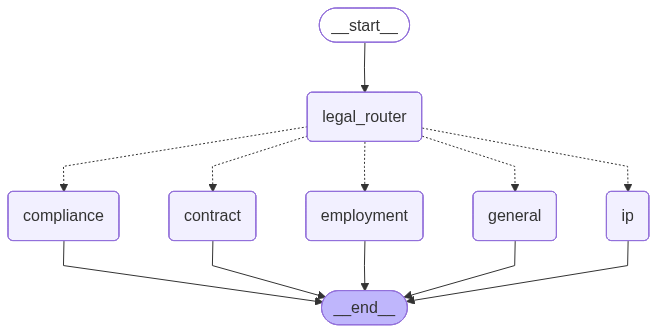

In [17]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Mermaid diagram (paste at https://mermaid.live):")
    print(app.get_graph().draw_mermaid())

## 🔧 Step 10 — The Helper Runner Function

In [18]:
from IPython.display import Markdown, display

# Legal domain emojis and full names for display
DOMAIN_DISPLAY = {
    "contract":   ("📝", "Contract Law"),
    "ip":         ("💡", "Intellectual Property"),
    "employment": ("👔", "Employment Law"),
    "compliance": ("🛡️",  "Regulatory Compliance"),
    "general":    ("🏛️",  "General Legal Counsel"),
}


def ask_legal(query: str, show_routing: bool = True) -> dict:
    """
    Ask the Legal Assistant a question.

    Args:
        query       : Legal question in plain English
        show_routing: Whether to show routing decision details

    Returns:
        final_state dict with all fields populated
    """
    print("\n" + "⚖️  " + "="*57)
    print(f"   LEGAL QUERY: {query}")
    print("="*60)

    initial_state = {
        "query":            query,
        "legal_domain":     "",     # Router fills this
        "confidence":       None,   # Router fills this
        "is_cross_domain":  None,   # Router fills this
        "secondary_domains": [],    # Router fills this
        "answer":           None,   # Specialist fills this
        "messages": [
            {"role": "user", "content": query}
        ]
    }

    final_state = app.invoke(initial_state)

    # Display formatted results
    print("\n" + "="*60)
    print("✅ LEGAL ASSISTANT RESPONSE")
    print("="*60)

    if show_routing:
        domain = final_state.get("legal_domain", "general")
        emoji, domain_name = DOMAIN_DISPLAY.get(domain, ("🏛️", domain))
        confidence   = final_state.get("confidence", 0)
        is_cross     = final_state.get("is_cross_domain", False)
        secondary    = final_state.get("secondary_domains", [])

        print(f"   Routed to   : {emoji} {domain_name}")
        print(f"   Confidence  : {confidence:.0%}")
        if is_cross:
            print(f"   Cross-domain: ⚠️  Yes — also touches: {', '.join(secondary)}")
        print()

    print("📋 LEGAL ANALYSIS:")
    print("-" * 60)
    display(Markdown(final_state.get("answer", "No answer generated.")))

    # Always show the legal disclaimer after every response
    print()
    print("⚠️  " + "-"*57)
    print("   DISCLAIMER: This is AI-generated legal information for")
    print("   educational purposes only. NOT legal advice. Always")
    print("   consult a licensed attorney for actual legal decisions.")
    print("-"*60)

    return final_state


print("✅ ask_legal() helper defined!")
print("   Usage: result = ask_legal('Is my NDA enforceable?')")

✅ ask_legal() helper defined!
   Usage: result = ask_legal('Is my NDA enforceable?')


## 🚀 Step 11 — Test: Contract Query

Expected route: `contract`

In [19]:
result = ask_legal(
    "Our vendor NDA has a perpetual confidentiality clause with no end date. "
    "Is this enforceable and should we be concerned?"
)


⚖️  =========================================================
   LEGAL QUERY: Our vendor NDA has a perpetual confidentiality clause with no end date. Is this enforceable and should we be concerned?

⚖️  LEGAL ROUTER: Classifying legal query...
   Query: "Our vendor NDA has a perpetual confidentiality clause with no end date. Is this enforceable and should we be concerned?"
   Primary domain  : contract
   Confidence      : 97%
   Cross-domain    : No
   Reason          : The query focuses on the enforceability of a vendor NDA clause, which is a contract law issue.
   🔀 Conditional Edge: routing to → contract

📝 CONTRACT AGENT: Analyzing contract query...
   Query       : "Our vendor NDA has a perpetual confidentiality clause with no end date. Is this enforceable and should we be concerned?"
   Cross-domain: False 
   ✅ Contract Agent responded!

✅ LEGAL ASSISTANT RESPONSE
   Routed to   : 📝 Contract Law
   Confidence  : 97%

📋 LEGAL ANALYSIS:
------------------------------------------

**1. Issue Identified**  
Whether a vendor‑provided NDA that contains a *perpetual* confidentiality obligation (no fixed end date) is enforceable, and what risks it poses to your company.

---

**2. Legal Analysis**  

| Element | Application to a Perpetual NDA |
|---------|--------------------------------|
| **Reasonableness of duration** – Under U.S. contract law, a confidentiality clause is enforceable only to the extent that its duration is *reasonable* in protecting the legitimate interests of the disclosing party. Courts typically look at (a) the nature of the information (trade secret vs. ordinary confidential data) and (b) how long that information is expected to retain its value. |
| **Trade‑secret information** – For true trade secrets, a *perpetual* duty can be upheld because the secret’s value may endure indefinitely, provided the holder takes reasonable steps to maintain secrecy. |
| **Non‑trade‑secret confidential information** – For ordinary business information (e.g., marketing plans, pricing lists) a perpetual term is often deemed **overbroad** and may be struck down or narrowed by a court. Many jurisdictions require the duty to last only as long as the information remains confidential or for a “reasonable period” (commonly 2‑5 years). |
| **State‑specific nuances** – Some states (e.g., California) are particularly skeptical of indefinite obligations and may invalidate them as an unreasonable restraint on trade. Others (e.g., New York) apply a more flexible “reasonable time” test. |
| **Drafting conventions** – Best practice is to tie the confidentiality period to the *life of the information* (e.g., “until the information no longer qualifies as a trade secret” or “for five (5) years after disclosure”). |
| **Remedies** – NDAs typically provide for injunctive relief. An overly broad perpetual clause can increase exposure to injunctive claims that are difficult to quantify, raising litigation risk. |
| **Potential conflicts with other clauses** – If the NDA also contains an “unlimited liability” or “no‑cure” provision, the perpetual duty can amplify the overall risk exposure. |

---

**3. Risk Assessment**  

| Risk | Level | Explanation |
|------|-------|-------------|
| **Enforceability challenge** | **Medium–High** | Courts may deem a blanket perpetual term unreasonable for non‑trade‑secret data, leading to partial invalidation or renegotiation. |
| **Over‑broad liability** | **High** | Your company could be held liable for inadvertent disclosure of information that, after a few years, is no longer sensitive, yet the NDA still obligates you. |
| **Compliance burden** | **Medium** | Ongoing monitoring to ensure no inadvertent disclosure for an indefinite period can be costly and operationally cumbersome. |
| **Negotiation leverage loss** | **Low–Medium** | Accepting a perpetual clause may signal willingness to accept other one‑sided terms. |
| **Potential for injunctive claims** | **Medium** | If a breach is alleged, the perpetual nature may make courts more willing to grant injunctive relief, even where damages are hard to assess. |

Overall risk: **Medium‑High** – the clause is not automatically unenforceable, but it carries significant practical and legal exposure.

---

**4. Recommendations**  

1. **Request a duration limitation**  
   * Propose a **fixed term** (e.g., 3‑5 years) for non‑trade‑secret information, and retain a **perpetual duty** only for bona‑fide trade‑secret data.  
   * Use language such as: “Confidentiality obligations shall continue for a period of five (5) years after the date of disclosure, except with respect to Trade Secrets, which shall remain confidential perpetually, provided they continue to qualify as Trade Secrets under applicable law.”

2. **Add a “survival” clause tied to the nature of the information**  
   * “Obligations shall survive until the Confidential Information (i) becomes publicly known through no fault of the Receiving Party, (ii) is independently developed, or (iii) no longer qualifies as a Trade Secret.”

3. **Insert a **reasonable‑use** carve‑out**  
   * Allow the Receiving Party to use the information for the specific purpose of the vendor relationship, then require return or destruction after the term ends.

4. **Include a **cure period** for inadvertent disclosures**  
   * “If a breach is discovered, the Receiving Party shall have thirty (30) days to cure the breach before the Disclosing Party may seek injunctive relief.”

5. **Clarify remedies**  
   * Limit remedies to injunctive relief *and* reasonable actual damages; avoid punitive or liquidated damages tied to the perpetual period.

6. **Assess state law**  
   * Identify the governing law clause in the NDA. If it designates a jurisdiction with a strong “reasonable time” requirement (e.g., California), prioritize renegotiation.

7. **Document internal controls**  
   * Implement a policy for tracking the classification of confidential data (trade secret vs. ordinary) and set automatic review dates (e.g., every 2‑3 years) to determine if the perpetual duty still applies.

8. **Escalate if the vendor refuses**  
   * If the vendor will not amend the clause, weigh the strategic importance of the relationship against the heightened risk. In high‑risk industries (e.g., technology, biotech), consider walking away or seeking alternative vendors.

---

**5. Attorney Note**  

- **Escalate to a qualified corporate attorney** if:  
  * The vendor insists on a blanket perpetual clause and the information includes sensitive non‑trade‑secret data.  
  * Your organization operates in a jurisdiction with strict “reasonable duration” standards (e.g., California) and you need a jurisdiction‑specific risk analysis.  
  * The NDA is part of a larger, complex agreement (e.g., master services agreement) where the perpetual clause may interact with indemnity, limitation of liability, or termination provisions.

---

**Disclaimer**  
The information provided above is for general educational purposes only and does not constitute legal advice. No attorney‑client relationship is formed by this communication. For advice tailored to your specific situation, please consult a licensed attorney.


⚠️  ---------------------------------------------------------
   DISCLAIMER: This is AI-generated legal information for
   educational purposes only. NOT legal advice. Always
   consult a licensed attorney for actual legal decisions.
------------------------------------------------------------


## 🚀 Step 12 — Test: IP Query

Expected route: `ip`

In [20]:
result = ask_legal(
    "We built our product using some open-source libraries licensed under GPL. "
    "Can we still sell our software commercially?"
)


⚖️  =========================================================
   LEGAL QUERY: We built our product using some open-source libraries licensed under GPL. Can we still sell our software commercially?

⚖️  LEGAL ROUTER: Classifying legal query...
   Query: "We built our product using some open-source libraries licensed under GPL. Can we still sell our software commercially?"
   Primary domain  : ip
   Confidence      : 98%
   Cross-domain    : Yes → also touches: ['compliance']
   Reason          : The core issue is open‑source licensing and rights to sell software, which falls under intellectual property law.
   🔀 Conditional Edge: routing to → ip

💡 IP AGENT: Analyzing intellectual property query...
   Query       : "We built our product using some open-source libraries licensed under GPL. Can we still sell our software commercially?"
   Cross-domain: True | Also: ['compliance']
   ✅ IP Agent responded!

✅ LEGAL ASSISTANT RESPONSE
   Routed to   : 💡 Intellectual Property
   Confidence  

**1. IP Type**  
- **Copyright** in the open‑source code, governed by the **GNU General Public License (GPL)** (or a GPL‑compatible license).  
- The question is about *licensing* rather than patents, trademarks, or trade‑secrets.

**2. Protection Status**  
- The GPL‑licensed libraries are already protected by copyright.  
- Your right to use them is *conditional* on complying with the GPL’s terms (the “copyleft” conditions).

**3. Key Issues**  

| Issue | Why it matters | Typical risk if ignored |
|-------|----------------|------------------------|
| **a. Copyleft obligations** | GPL‑v2/v3 require that any *derivative work* that you distribute must be licensed as a whole under the same GPL and that you provide the complete, corresponding source code (including build scripts, makefiles, etc.). | Distribution of a binary without source or with a more restrictive license can be deemed copyright infringement → cease‑and‑desist, damages, injunction. |
| **b. “Commercial” vs. “free”** | GPL does **not** prohibit commercial sale. It only requires that the recipient receives the same freedoms you received. | Misunderstanding that GPL forbids selling can lead to abandoning valuable components unnecessarily. |
| **c. Scope of “derivative work”** | If you merely *link* to a GPL library (static linking in many jurisdictions, or dynamic linking that creates a combined work), the resulting program is usually considered a derivative work and must be GPL‑licensed. (If you use a **LGPL** library, the rules are looser.) | Treating a linked GPL library as “just an API” and keeping your code proprietary can expose you to infringement claims. |
| **d. Distribution model** | – **On‑premise software**: you can sell the binary, but you must also make the source available (e.g., via a download link) under the same GPL. <br>– **Software‑as‑a‑Service (SaaS)**: If the library is **GPL‑v3**, the normal GPL does *not* trigger source‑distribution obligations for SaaS; however, if it is **AGPL**, you must provide the source to any user who interacts with the service. | Ignoring the AGPL SaaS clause can lead to violation even though you never ship code. |
| **e. License compatibility** | If you combine GPL code with other third‑party components that have incompatible licenses (e.g., a proprietary SDK), the whole combined work may be *unlicensable*. | You may be forced to either replace the GPL component or obtain a separate commercial license from the upstream author. |
| **f. Patent grants** | GPL‑v3 includes an implicit patent‑license from contributors to downstream recipients. If you hold patents that read on the GPL code, you must grant a royalty‑free license to downstream users, or you may be in breach of the GPL. | Potential patent litigation or loss of GPL rights. |
| **g. Jurisdictional nuances** | The definition of “derivative work” can vary (U.S. vs. EU vs. other). In the U.S., static linking is more likely to be seen as creating a derivative work; in some other jurisdictions the analysis may differ. | A mis‑analysis could lead to an unexpected infringement exposure. |

**4. Jurisdiction Note**  
- The GPL is a *global* license, but enforcement and the *derivative‑work* test can differ by country.  
- **If your primary market is the United States, the analysis above (static linking = derivative work) applies.**  
- **If you are selling internationally (EU, Canada, etc.), let us know the key jurisdictions so we can tailor the risk assessment.**

**5. Action Steps**  

| Step | What to do | Who should do it | Approx. timeline |
|------|------------|------------------|------------------|
| **a. Identify every GPL‑licensed component** (including transitive dependencies). | Run a software composition analysis (SCA) tool (e.g., FOSSA, Black Duck) and produce a bill of materials. | Development/DevOps team + IP counsel. | 1–2 weeks. |
| **b. Determine the exact GPL version** (GPL‑v2, GPL‑v3, AGPL‑v3) for each component. | Review each library’s LICENSE file or upstream repo. | Same as above. | Concurrent with (a). |
| **c. Conduct a GPL compliance audit**: <br>‑ Confirm that your product is a *derivative work* (static link, inclusion of source, etc.). <br>‑ Draft a “source‑code distribution” plan (e.g., provide a downloadable source archive, include a copy of the GPL, and a written offer to provide source on request). | IP attorney (or specialist counsel) + engineering lead. | 2–4 weeks (depends on product size). |
| **d. Decide on a licensing strategy**: <br>1️⃣ **Comply** – Release your entire product under the same GPL (or LGPL if possible). <br>2️⃣ **Replace** – Swap out GPL components for permissive‑licensed or internally developed alternatives. <br>3️⃣ **Obtain a commercial license** – Contact the upstream authors for a proprietary license (if they offer one). | Business leadership + legal counsel. | 1–3 months (including any negotiations). |
| **e. Update your distribution process**: <br>‑ Add the source‑code download link to every binary distribution. <br>‑ Include the full GPL text and any required notices in your installer/README. | Release engineering. | Ongoing, after (c). |
| **f. Patent‑license check** (if you hold relevant patents). | Ensure any patents that read on the GPL code are licensed royalty‑free to downstream users, or consider a patent‑pursuit strategy. | Patent counsel. | 1–2 weeks. |
| **g. Document everything**: Keep records of the audit, the source‑code offer, and correspondence with upstream authors. | Legal operations. | Ongoing. |
| **h. Consult compliance specialists** (e.g., data‑privacy, export‑control) if your software processes regulated data or is subject to export restrictions. | Compliance team. | Parallel to (c)–(e). |

**6. Timeline & Cost (ballpark)**  

| Activity | Typical cost (U.S.) | Time needed |
|----------|----------------------|--------------|
| SCA tool licensing / scan | $2 k–$10 k (one‑time or annual) | 1–2 weeks |
| GPL compliance audit (law firm) | $5 k–$20 k (depends on product size) | 2–4 weeks |
| Re‑engineering/re‑licensing (if you replace components) | $10 k–$100 k+ (development effort) | 1–6 months |
| Patent‑license review (if applicable) | $3 k–$8 k | 1–2 weeks |
| Ongoing monitoring (continuous compliance) | $1 k–$3 k per month (or internal staff) | Ongoing |

**Bottom‑line answer:**  

- **Yes, you can sell the software commercially** even when it incorporates GPL‑licensed libraries, **provided you satisfy the GPL’s copyleft conditions** (release the full corresponding source code under the same GPL, include the license text, and grant downstream recipients the same rights).  

- If you wish to keep your own code *proprietary*, you must **replace or obtain a separate commercial license** for the GPL components.  

- Failure to comply can expose you to copyright infringement claims, injunctions, and potential damages.  

- Because the analysis hinges on the exact way you link/ integrate the GPL code and on the jurisdictions where you sell, **please confirm the primary markets** (U.S., EU, etc.) and whether any of the libraries are AGPL.  

- I recommend proceeding with steps **(a)–(c)** immediately and scheduling a follow‑up meeting once the audit results are in, so we can decide whether to **comply** or **replace** the GPL code.  

**Next step:** let me know the jurisdictions you target and the specific GPL versions involved, and we’ll draft a detailed compliance roadmap and estimate the precise budget.


⚠️  ---------------------------------------------------------
   DISCLAIMER: This is AI-generated legal information for
   educational purposes only. NOT legal advice. Always
   consult a licensed attorney for actual legal decisions.
------------------------------------------------------------


## 🚀 Step 13 — Test: Employment Query

Expected route: `employment`

In [21]:
result = ask_legal(
    "We want to put non-compete clauses in all new employee contracts. "
    "We're a startup based in California. Is this a good idea?"
)


⚖️  =========================================================
   LEGAL QUERY: We want to put non-compete clauses in all new employee contracts. We're a startup based in California. Is this a good idea?

⚖️  LEGAL ROUTER: Classifying legal query...
   Query: "We want to put non-compete clauses in all new employee contracts. We're a startup based in California. Is this a good idea?"
   Primary domain  : employment
   Confidence      : 97%
   Cross-domain    : Yes → also touches: ['contract']
   Reason          : The core issue is the enforceability of non‑compete clauses in employee agreements, which is an employment law matter, though it also involves contract drafting.
   🔀 Conditional Edge: routing to → employment

👔 EMPLOYMENT AGENT: Analyzing employment law query...
   Query       : "We want to put non-compete clauses in all new employee contracts. We're a startup based in California. Is this a good idea?"
   Cross-domain: True | Also: ['contract']
   ✅ Employment Agent responded!


**1. Legal Issue**  
Can a California‑based startup include a blanket non‑compete clause in every new employee agreement, and what are the consequences of doing so?

---

**2. Federal Law**  
There is no federal statute that directly validates or invalidates non‑compete agreements. Federal law (e.g., Title VII, ADA, ADEA) does not prohibit non‑competes, but it does require that any restrictive covenant not discriminate on the basis of a protected class. In practice, the enforceability of a non‑compete is governed almost entirely by state law.

---

**3. State Law Note (California)**  
California is the **most restrictive** jurisdiction in the United States regarding non‑compete agreements:

| Provision | California Position |
|-----------|---------------------|
| **General non‑compete** | **Void as a matter of public policy** – Business and Professions Code § 16600 declares that “every contract by which anyone is restrained from engaging in a lawful profession, trade, or business of any kind is to that extent void.” |
| **Exceptions** | Only three narrow categories are permitted: <br>1. **Sale of a business** – a covenant that is part of a purchase agreement to protect the buyer’s goodwill.<br>2. **Dissolution of a partnership or LLC** – a covenant that protects the departing partner’s interest.<br>3. **Trade‑secret protection** – a covenant that is limited to preventing the misappropriation of trade secrets (Cal. Civ. Code §§ 3426‑3429). |
| **Non‑solicitation / Confidentiality** | Generally enforceable when narrowly tailored to protect confidential information or client relationships, provided they do not amount to an unlawful restraint on the employee’s ability to work. |
| **FTC “non‑compete ban”** | The FTC has issued a proposed rule to ban non‑competes nationwide, but it has **not yet become law** and does not change California’s existing rule. |

**Bottom line:** A blanket non‑compete clause in every new employee contract is **unenforceable in California** and can expose the company to legal and reputational risk.

---

**4. Risk Assessment**  

| Risk | Likelihood | Potential Impact |
|------|------------|------------------|
| **Clause deemed void** | Near‑certain (California law) | No protection; the clause is unenforceable, and the employee can ignore it. |
| **Employee claims of unlawful restraint** | High if clause is used widely | May trigger a **California Labor Code** claim for “unlawful restraint of trade,” possible civil penalties, and attorney fees. |
| **Bad‑faith litigation / defensive costs** | Moderate | Even if the clause is void, a disgruntled employee may sue, forcing the company to spend time and money defending a claim that will ultimately fail. |
| **Negative employer brand / morale** | Moderate‑high | Employees (especially in a startup environment) often view non‑competes as hostile, hurting recruitment and retention. |
| **Impact on multi‑state employees** | Variable | If you later hire employees in states that *do* enforce non‑competes, a one‑size‑fits‑all clause could be partially enforceable elsewhere but still void in California, creating inconsistency and compliance headaches. |

Overall, proceeding with a blanket non‑compete in California presents **high legal risk with little to no protective benefit**.

---

**5. Recommended Actions**  

1. **Remove the blanket non‑compete** from all standard employee agreements for California hires.  
2. **Adopt alternative, enforceable protective tools**:  
   - **Confidentiality Agreement (NDA)** – protect proprietary information, source code, business plans, etc.  
   - **Trade‑Secret Agreement** – reference California’s Uniform Trade Secrets Act (UTSA) (Cal. Civ. Code §§ 3426‑3429) and require employees to return all confidential materials upon termination.  
   - **Limited Non‑Solicitation Clause** – prohibit former employees from soliciting the company’s *customers* or *employees* for a reasonable period (typically 6–12 months). Ensure the clause is narrowly tailored to avoid being treated as an unlawful non‑compete.  
   - **Garden‑Leave/Severance Agreements (if desired)** – you may offer voluntary severance or “garden‑leave” payments in exchange for a release of claims. Such agreements must comply with the ADEA waiver timing (21‑day consideration period + 7‑day revocation) and California’s stricter standards for waivers (must be knowing, voluntary, and supported by consideration).  
3. **Tailor agreements by work location**:  
   - For any employees who will be based **outside California**, draft a separate agreement that complies with the law of that state (e.g., a reasonable non‑compete for Texas, Illinois, etc.).  
   - Include a **choice‑of‑law clause** that specifies the governing state, but remember that California courts will not enforce a non‑compete for a California‑based employee even if the contract says “governed by New York law.”  
4. **Implement robust onboarding and exit processes**:  
   - Provide clear written policies on confidentiality and trade‑secret protection.  
   - Conduct exit interviews and have departing employees sign a **return‑of‑property and confidentiality acknowledgment**.  
5. **Educate managers and HR** on the limits of restrictive covenants in California to avoid inadvertently imposing illegal restraints (e.g., “don’t work for a competitor for six months” statements).  

---

**6. Documentation Checklist**  

| Document | What to Include / Keep |
|----------|------------------------|
| **Employee Offer Letter / Employment Agreement** | • Clear statement that employment is at‑will (unless otherwise agreed). <br>• No non‑compete clause for California hires. |
| **Confidentiality / Trade‑Secret Agreement** | • Definition of confidential information and trade secrets. <br>• Employee obligations during and after employment. <br>• Acknowledgment of California UTSA. |
| **Non‑Solicitation Clause (if used)** | • Specific scope (customers vs. employees). <br>• Reasonable time limit (e.g., 12 months). |
| **Severance / Release Agreement (if offered)** | • Detailed consideration (e.g., severance pay, continued benefits). <br>• ADEA waiver timing compliance (21‑day consideration + 7‑day revocation). <br>• Explicit waiver of claims under California law (must be knowing and voluntary). |
| **Employee Handbook / Policies** | • Confidentiality, data‑security, and trade‑secret policies. <br>• Procedure for reporting suspected misuse. |
| **Exit‑Interview Checklist** | • Confirmation of returned equipment, documents, and electronic access. <br>• Signed acknowledgment of continuing confidentiality obligations. |
| **State‑Specific Addenda** (if you have out‑of‑state employees) | • Separate non‑compete language that meets the applicable state’s reasonableness test. <br>• Choice‑of‑law and forum selection provisions. |

---

### Bottom Line

For a **California‑based startup**, inserting a blanket non‑compete clause into every new employee contract is **not a good idea**. California law renders such clauses void, exposing you to legal risk, potential claims, and negative employee perception. Instead, rely on **confidentiality, trade‑secret, and narrowly tailored non‑solicitation provisions**, and ensure any restrictive covenants for employees outside California are drafted to meet the specific state’s requirements.

If you need help drafting California‑compliant agreements or tailoring contracts for multi‑state hires, let us know—we can provide templates and a review checklist to keep you fully protected.


⚠️  ---------------------------------------------------------
   DISCLAIMER: This is AI-generated legal information for
   educational purposes only. NOT legal advice. Always
   consult a licensed attorney for actual legal decisions.
------------------------------------------------------------


## 🚀 Step 14 — Test: Compliance Query

Expected route: `compliance`

In [22]:
result = ask_legal(
    "We just discovered our database was breached and it may contain "
    "EU customer data. What are our legal obligations and how quickly "
    "do we need to act?"
)


⚖️  =========================================================
   LEGAL QUERY: We just discovered our database was breached and it may contain EU customer data. What are our legal obligations and how quickly do we need to act?

⚖️  LEGAL ROUTER: Classifying legal query...
   Query: "We just discovered our database was breached and it may contain EU customer data. What are our legal obligations and how quickly do we need to act?"
   Primary domain  : compliance
   Confidence      : 98%
   Cross-domain    : No
   Reason          : The query focuses on legal obligations and response timelines for a data breach involving EU personal data, which falls under GDPR compliance.
   🔀 Conditional Edge: routing to → compliance

🛡️  COMPLIANCE AGENT: Analyzing compliance query...
   Query       : "We just discovered our database was breached and it may contain EU customer data. What are our legal obligations and how quickly do we need to act?"
   Cross-domain: False 
   ✅ Compliance Agent responded

**Regulatory Compliance Quick‑Start for a Possible EU‑Resident Data Breach**

Below is a concise, step‑by‑step analysis using the firm’s standard framework. It focuses on the GDPR because the breach involves personal data of EU customers. If you also handle other regulated data (e.g., PHI, credit‑card data, California consumer data), you’ll need to layer the relevant obligations on top of what is outlined here.

---

## 1. Applicable Regulation(s)

| Regulation | Why it may apply |
|------------|-----------------|
| **GDPR (EU General Data Protection Regulation)** | You process personal data of individuals located in the EU, regardless of where your company is incorporated. |
| **National EU data‑protection laws** (e.g., German BDSG, French CNIL rules) | May impose additional reporting or documentation requirements. |
| **Potential secondary regimes** (e.g., **UK GDPR**, **CCPA/CPRA**, **HIPAA**, **PCI‑DSS**) | Only relevant if the same breach also contains data covered by those statutes. Mentioned here for completeness; not the primary focus. |

---

## 2. Applicability Check

| Question | Typical Answer | Implication |
|----------|----------------|-------------|
| **Do you process personal data of EU‑resident individuals?** | *Yes* – the database is known to contain EU customer data. | GDPR applies. |
| **Is any of that data “special category” (e.g., health, biometric, political opinion)?** | *If yes* → higher scrutiny, possible DPO requirement, stricter breach‑impact analysis. |
| **Do you have a Data Protection Officer (DPO) or a designated privacy lead?** | *If not* → you must appoint one (or at least designate a responsible person) promptly because a breach triggers mandatory DPO involvement under GDPR Art. 33‑34. |
| **Do you use third‑party processors (cloud, SaaS, hosting) that store or handle the data?** | *If yes* → you must verify that a valid Data Processing Agreement (DPA) is in place and that the processor will cooperate with breach notifications. |
| **Are any cross‑border transfers involved?** | *If data moves from EU to a non‑EU country* → you must have a lawful transfer mechanism (e.g., SCCs, EU‑US Data Privacy Framework, BCRs). A breach may affect the adequacy assessment of those mechanisms. |

---

## 3. Key GDPR Requirements When a Breach Occurs

| Requirement | What You Must Do |
|-------------|------------------|
| **Detect & Contain** | Immediately isolate the compromised system, stop further exfiltration, preserve forensic evidence (logs, snapshots). |
| **Risk Assessment** | Within the first **few hours**, assess the nature, scope, and likely impact of the breach (type of data, volume, sensitivity, likelihood of harm). |
| **Notify the Supervisory Authority (SA)** | **Within 72 hours** of becoming aware of the breach, submit a **Data Breach Notification** to the lead SA (or the relevant SA(s) if multiple EU states are involved). The notice must include: <br>• Description of the breach (what happened, when, how). <br>• Categories and approximate number of data subjects affected. <br>• Categories and approximate number of records concerned. <br>• Likely consequences for the individuals. <br>• Measures taken or proposed to mitigate the breach. |
| **Notify Affected Data Subjects** | If the breach is **likely to result in a high risk** to the rights and freedoms of individuals, you must communicate **without undue delay** (generally within a few days after the SA notice) a clear, plain‑language description of: <br>• What happened. <br>• What data is involved. <br>• Potential risks. <br>• Steps they can take (e.g., password changes, monitoring). <br>• What you are doing to address the breach. |
| **Document the Breach Internally** | Maintain a detailed **Record of the Breach** (Art. 33(5) GDPR) for at least 2 years, covering the investigation, decisions, notifications, and remedial actions. |
| **Involve the DPO** | The DPO must be **consulted** before any notification is sent (Art. 33(1) GDPR). |
| **Review Transfer Mechanisms** | If you rely on SCCs or the EU‑US Data Privacy Framework, verify that the breach does not invalidate the adequacy or contractual safeguards. You may need to inform the counterparties and possibly renegotiate. |
| **Potential Fines & Liability** | Non‑compliance can lead to administrative fines up to **€20 million or 4 % of global annual turnover**, whichever is higher. |

---

## 4. Gaps & Risks Specific to Your Situation

| Area | Typical Gap | Associated Risk |
|------|------------|-----------------|
| **Breach‑Response Plan** | No documented, tested incident‑response (IR) procedure. | Delayed detection, missed 72‑hour window, higher fines. |
| **DPO / Privacy Lead** | No appointed DPO or unclear responsibilities. | Non‑compliance with Art. 33/34 consultation requirement; possible regulatory scrutiny. |
| **Data Mapping & Inventory** | Incomplete records of where EU data resides (cloud, backups, on‑prem). | Difficulty assessing scope → delayed or inaccurate notifications. |
| **Data Processing Agreements (DPAs)** | Missing or outdated DPAs with third‑party processors. | Processor may not be contractually obligated to assist with breach reporting; regulator may view you as failing to ensure processor compliance. |
| **Cross‑Border Transfer Mechanisms** | Using old SCC versions (pre‑2021) or no adequacy decision for US transfers. | SCCs may be invalid; breach could trigger additional scrutiny and require renegotiation. |
| **Security Controls** | Insufficient technical safeguards (encryption at rest, multi‑factor authentication, logging). | Higher likelihood of breach recurrence; may be deemed “lack of appropriate technical and organisational measures” (Art. 32 GDPR). |
| **Documentation** | No central breach log or evidence‑preservation policy. | Inability to produce required records → regulatory penalties. |
| **Consumer‑Facing Communications** | No template for breach notices to EU data subjects. | Risk of non‑compliant, confusing, or legally insufficient notifications. |

---

## 5. Action Plan (Prioritized)

| Priority | Action | Owner(s) | Target Completion |
|----------|--------|----------|--------------------|
| **1 – Immediate Containment** | Isolate affected systems, block further exfiltration, preserve logs & forensic images. | IT Security / Incident Response Team | **Within 4 hours** |
| **2 – Initial Assessment** | Conduct a rapid “facts‑finding” sprint: identify data types, number of records, sensitivity, and affected EU jurisdictions. | Privacy Lead + IR Team | **Within 8 hours** |
| **3 – Notify DPO / Legal** | Escalate to DPO (or appoint one) and corporate counsel for guidance on notification content. | CEO / CIO | **Within 8 hours** |
| **4 – Draft SA Notification** | Prepare the mandatory 72‑hour report (use regulator‑specific template if available). | DPO + Legal | **Within 24 hours** |
| **5 – Submit SA Notification** | Send to the lead Supervisory Authority (or multiple if multi‑state). Use secure channel (e.g., encrypted email, portal). | DPO | **Within 72 hours** |
| **6 – High‑Risk Evaluation** | Apply the GDPR “high‑risk” test (Art. 33(2)). If high risk, prepare data‑subject notice. | DPO + Risk Management | **Within 48 hours of SA submission** |
| **7 – Data‑Subject Communication** | Draft clear, plain‑language notice (including remedial steps, contact info). Publish on website & send via email/letter as appropriate. | DPO + Communications | **As soon as possible after high‑risk determination (generally < 5 days total)** |
| **8 – Internal Documentation** | Complete the breach register entry (facts, decisions, notifications, remediation). Store securely for 2 years. | Compliance Officer | **Within 7 days** |
| **9 – Forensic Review & Root‑Cause Analysis** | Full technical investigation to understand cause, assess whether additional controls are needed. | IT Security | **Within 2 weeks** |
| **10 – Remediation & Controls Upgrade** | Implement recommended security measures (encryption, MFA, patching, monitoring). Update DPAs if needed. | IT & Procurement | **Within 30 days** |
| **11 – Review Transfer Mechanisms** | Verify SCCs or EU‑US Framework are current; renegotiate if breach exposed gaps. | Data Protection & Legal | **Within 30 days** |
| **12 – Conduct Formal Privacy Audit** | Engage an external auditor (or internal audit team) to assess overall GDPR compliance post‑incident. | Audit Committee | **Within 60 days** |
| **13 – Staff Training Refresh** | Run GDPR breach‑response and data‑handling refresher for all employees handling EU data. | HR / Privacy | **Within 90 days** |

*Adjust timelines based on your organization’s size, complexity, and the exact time you become “aware” of the breach (the clock starts at awareness, not discovery).*

---

## 6. Deadline Alert

| Deadline | What Must Be Done | Consequence of Miss |
|----------|-------------------|---------------------|
| **72 hours from awareness** | Submit breach notification to the relevant Supervisory Authority (Art. 33 GDPR). | Potential administrative fine; regulator may consider the breach “unreported” and impose up to €20 M or 4 % of turnover. |
| **“Without undue delay” (typically ≤ 7 days)** | Notify affected EU data subjects if the breach poses a high risk (Art. 34 GDPR). | Failure can lead to additional fines and reputational damage; may trigger class‑action lawsuits. |
| **2 years** | Retain the breach record (including investigation, decisions, notifications). | Regulators may request evidence; lack of records can increase penalties. |
| **Ongoing** | Ensure any cross‑border transfer mechanisms remain valid (e.g., SCCs updated 2021 version). | Invalid transfers can be deemed unlawful processing, exposing you to fines and requiring data deletion or repatriation. |

---

### Quick‑Check Checklist (Copy‑Paste for Your Team)

```
[ ] Contain breach – isolate systems, preserve logs.
[ ] Identify EU personal data involved (type, volume, sensitivity).
[ ] Assess risk – does it likely cause high risk to individuals?
[ ] Notify DPO/legal immediately.
[ ] Draft & send SA notification (≤ 72 h from awareness).
[ ] If high risk → draft data‑subject notice (send ≤ 7 days).
[ ] Record breach details in internal register (keep ≥ 2 years).
[ ] Verify DPAs and transfer mechanisms (SCCs/EU‑US Framework) are current.
[ ] Conduct forensic root‑cause analysis.
[ ] Implement remediation (encryption, MFA, patching, monitoring).
[ ] Schedule formal GDPR compliance audit.
[ ] Refresh staff privacy & security training.
```

---

### Final Note

- **Verify dates**: The 72‑hour clock starts when you **first become aware** of the breach (not when you confirm its scope). If you discovered the breach today, you have until **Day 3, same time of day** to notify the SA.
- **Official sources**: Consult the specific Supervisory Authority’s breach‑notification portal (e.g., CNIL, ICO, BfDI) for any country‑specific forms or additional deadlines.
- **Legal counsel**: Because breach notifications can have significant legal and reputational impact, have your in‑house or external counsel review the notification drafts before submission.

If you need a template for the GDPR breach report, a sample DPO‑consultation checklist, or guidance on updating your SCCs, let me know and I can provide those resources. Stay swift—time is the most critical factor in GDPR breach compliance.


⚠️  ---------------------------------------------------------
   DISCLAIMER: This is AI-generated legal information for
   educational purposes only. NOT legal advice. Always
   consult a licensed attorney for actual legal decisions.
------------------------------------------------------------


## 🚀 Step 15 — Test: Cross-Domain Query (The Hard One)

This query touches **Employment + IP** — the router should detect cross-domain.
Watch how the specialist agent acknowledges both dimensions!

In [23]:
result = ask_legal(
    "An employee built an AI tool on their own time, but used our company laptop "
    "and it solves a problem similar to what we're working on. Who owns the IP?"
)


⚖️  =========================================================
   LEGAL QUERY: An employee built an AI tool on their own time, but used our company laptop and it solves a problem similar to what we're working on. Who owns the IP?

⚖️  LEGAL ROUTER: Classifying legal query...
   Query: "An employee built an AI tool on their own time, but used our company laptop and it solves a problem similar to what we're working on. Who owns the IP?"
   Primary domain  : employment
   Confidence      : 78%
   Cross-domain    : Yes → also touches: ['ip']
   Reason          : The core issue concerns the employee's rights and obligations regarding work‑product, placing it primarily under employment law, while also involving IP ownership.
   🔀 Conditional Edge: routing to → employment

👔 EMPLOYMENT AGENT: Analyzing employment law query...
   Query       : "An employee built an AI tool on their own time, but used our company laptop and it solves a problem similar to what we're working on. Who owns the IP?"

**1. Legal Issue**  
Who owns the intellectual‑property (IP) in an AI tool that an employee created on his/her own time, but (a) used a company laptop and (b) solves a problem that is “similar” to the company’s current project?

---

**2. Federal Law**  

| Area | What the law says | Practical impact |
|------|-------------------|------------------|
| **Patent Act (35 U.S.C. §§ 101‑291)** | An invention is a *“work‑for‑hire”* (and therefore belongs to the employer) **only** if it is created **within the scope of employment**.  The “scope of employment” test looks at (1) whether the employee was hired to perform the type of work the invention relates to, and (2) whether the invention was made **while the employee was on the clock or using employer resources**. | If the employee was hired to develop AI solutions for the same problem, the invention may be deemed “within the scope of employment” even if done off‑hours.  Using a company laptop is a strong indicium of using employer resources. |
| **Copyright Act** | Works created by an employee as part of his/her job are “works made for hire” and belong to the employer.  For works created **outside** the scope of employment, ownership stays with the creator unless there is an **assignment agreement**. | Code (source, models, documentation) written on a company device can be treated as a work‑made‑for‑hire if the employer can show the employee was acting in the course of employment. |
| **Trade‑Secret Law (UTSA & Defend Trade Secrets Act)** | If the AI tool incorporates confidential information or trade‑secret knowledge of the employer, the employer may assert a trade‑secret claim regardless of who wrote the code. | Using the laptop could expose the employer’s confidential data to the new tool, creating a trade‑secret risk. |
| **Employment‑contract / Assignment provisions** | Federal law does **not** dictate the content of invention‑assignment clauses, but courts enforce them if they are **clear, reasonable, and not contrary to public policy**. | Most companies require employees to sign an “Invention Assignment Agreement” (IAA) that assigns any invention “related to the employer’s business” (or “any invention conceived using any of the employer’s equipment, supplies, or facilities”) to the employer. |
| **No direct federal IP‑ownership statute** | Ownership is largely governed by contract, state law, and the “scope of employment” analysis. | The employer’s risk hinges on the existence and wording of the IAA and any IP policy. |

---

**3. State Law Note**  

State law can dramatically alter the analysis, especially in **California, Washington, New York, Massachusetts, and other “inventor‑friendly” jurisdictions**.

| State | Key points |
|-------|------------|
| **California (Cal. Labor Code §§ 2870‑2872)** | *Any* invention developed **outside** the employee’s duties and **without using the employer’s equipment, supplies, facilities, or trade‑secret information* belongs to the employee, **even if the invention is related to the employer’s business**.  However, the employee **must disclose** the invention within a reasonable time and **assign** any invention that was made **using the employer’s equipment or trade‑secret information**. |
| **Washington (RCW 49.12.020)** | Similar “invention assignment” statutes but with a “reasonable time” disclosure requirement; the employer can claim ownership of inventions made **on employer time or with employer resources**. |
| **New York, Massachusetts, Texas, etc.** | Courts generally enforce broad assignment clauses, but they will not assign inventions that are **completely unrelated** to the employer’s business and **created on the employee’s own time and equipment**.  Use of company equipment can tip the balance toward employer ownership. |
| **Other states** | Many follow the “scope‑of‑employment” test; some have “shop‑rights” doctrines that give the employer a **non‑exclusive license** to use inventions made with employer resources. |

**Action:** *Ask the employee (or you) what state the employer is headquartered in and where the employee works.*  That will determine which statutory provisions apply.

---

**4. Risk Assessment**  

| Risk | Likelihood (if no steps taken) | Potential exposure |
|------|------------------------------|--------------------|
| **Employer claim of ownership** | High if an **invention‑assignment agreement** exists that covers “inventions related to the business” *or* “inventions made using company equipment”. | Litigation, injunction, possible damages/royalties, loss of the AI tool. |
| **Employee claim of ownership** | High if the state (e.g., CA) protects “outside‑the‑scope” inventions and the employee can show the tool was created on personal time and the laptop was merely a convenience. | Employer may have to license the tool, or may be barred from using it. |
| **Trade‑secret exposure** | Moderate‑High.  If the tool incorporates any confidential data, the employee could be sued for misappropriation. | Injunctive relief, damages, reputational harm. |
| **Copyright infringement** | Low‑moderate, unless the code contains third‑party open‑source components with incompatible licenses. | Potential DMCA takedown or license‑violation claims. |
| **Future enforcement of non‑compete / non‑solicitation** | Depends on jurisdiction; a non‑compete that tries to block the employee from using his own invention could be invalid in many states. | Unnecessary litigation risk. |
| **Employee morale / whistle‑blowing** | If the employer aggressively claims ownership without clear policy, it may trigger a retaliation claim if the employee complains. | EEOC/State‑agency complaint. |

**Bottom line:** Proceeding **without** a clear, written determination of ownership creates a **significant litigation risk** (especially in states with strong employee‑inventor protections) and could jeopardize the company’s ability to use the AI tool.

---

**5. Recommended Actions**  

| Step | Why / How |
|------|-----------|
| **1. Locate & Review All Relevant Agreements** | • Employment contract<br>• Invention Assignment Agreement (IAA)<br>• Company IP / “Use of Company Equipment” policy<br>• Confidentiality / NDA<br>These documents dictate the contractual baseline. |
| **2. Identify Governing State Law** | Confirm the state(s) that apply (headquarters, work location). This determines whether the employee automatically retains rights (e.g., CA) or the employer gets a broader claim. |
| **3. Conduct a Fact‑Finding Interview (documented)** | Ask the employee to provide a written chronology: <br>• Date(s) and time(s) the tool was conceived and coded<br>• Whether any company time was spent (e.g., during lunch, after hours on company network)<br>• Exact equipment used (company laptop, network, software licenses)<br>• Whether any company confidential information or trade secrets were used. |
| **4. Issue a Formal Invention Disclosure** | Even if the employee believes he/she owns the IP, a written disclosure triggers the contractual “notice” obligations (especially in CA). The disclosure should be filed with the company’s IP committee or legal department. |
| **5. Evaluate Ownership under the “Scope‑of‑Employment” Test** | • If the employee was hired **to solve the same problem** and used a **company laptop**, a strong argument exists that the invention was made **within the scope of employment** → employer ownership.<br>• If the employee’s role is unrelated and the laptop was used only as a convenience, the employee may retain ownership, but the employer likely gets a **non‑exclusive, royalty‑free license** (shop‑rights). |
| **6. Draft a Settlement / Assignment Agreement (if needed)** | • If the employer wishes to own the tool, have the employee **assign** the IP in exchange for consideration (e.g., a bonus, royalty, or a severance‑type payment).<br>• If the employee retains ownership, negotiate a **license** (e.g., perpetual, royalty‑free, worldwide) that lets the company use the tool. |
| **7. Update or Implement Clear IP Policies** | • Require that **all company equipment be used only for company business**.<br>• Clarify that any invention made **using company resources** is automatically assigned to the employer.<br>• Provide a “personal‑project” carve‑out that specifies the employee must **not use** company hardware, software, or confidential data. |
| **8. Conduct Training** | Remind staff (especially engineers, data scientists, R&D) about the policy and the need to disclose any side projects that could overlap with company work. |
| **9. Preserve Evidence** | Keep copies of the employee’s code, email trails, system logs (showing laptop usage), and the signed disclosure/assignment documents. This protects the company if a dispute arises. |
| **10. Consult a Patent Attorney** | For a definitive determination of patent ownership (including filing of provisional applications), involve counsel experienced in patent‑law and employment‑IP matters. |

---

**6. Documentation Checklist**  

| Document | Purpose |
|----------|---------|
| **Signed Employment Contract** (including at‑will language) | Baseline of the employment relationship. |
| **Invention Assignment Agreement (IAA)** | Shows contractual assignment of inventions. |
| **Company IP / Equipment Use Policy** (acknowledged by employee) | Demonstrates the employee was on notice that using company assets creates employer ownership. |
| **Employee’s Written Invention Disclosure** (date‑stamped) | Satisfies notice requirements and creates a paper trail. |
| **Fact‑Finding Interview Notes / Email from Employee** | Evidence of the circumstances (time, resources, knowledge used). |
| **System Logs / Asset Utilization Records** (e.g., laptop login times, network access logs) | Objective proof of equipment use. |
| **Draft Assignment / License Agreement** (if executed) | Final legal instrument transferring or licensing rights. |
| **Correspondence with Patent Attorney** | Shows due‑diligence on patent ownership. |
| **Training Materials / Attendance Records** | Evidence of proactive policy enforcement. |
| **Any Prior Art / Related Company Projects** | Helps assess similarity and “related‑to‑business” analysis. |

---

### Quick Take‑Away

| Situation | Likely Owner |
|-----------|--------------|
| **Employee invented the tool on personal time **and** used only personal equipment** | **Employee** (unless a very broad assignment clause covers “any invention related to the business”). |
| **Employee used a company laptop (or any company resource) to develop the tool** | **Employer** in most states (especially if the employee’s job duties involve AI/ML work).  In California, the employee still owns the invention **but the employer gets a royalty‑free license** and the employee must assign any invention made **using employer equipment**. |
| **The tool incorporates company confidential data or trade‑secret algorithms** | **Employer** (trade‑secret misappropriation claim) – employee likely must assign or license the IP. |

**Bottom line:** The decisive factor is **(a) the contractual assignment language**, **(b) the state’s statutory rule on employee inventions**, and **(c) whether any company resources (including the laptop) were used**.  Secure a written disclosure, evaluate the facts against the contract and state law, and then either assign the IP to the company or negotiate a license—while updating policies to avoid a repeat scenario.


⚠️  ---------------------------------------------------------
   DISCLAIMER: This is AI-generated legal information for
   educational purposes only. NOT legal advice. Always
   consult a licensed attorney for actual legal decisions.
------------------------------------------------------------


## 🚀 Step 16 — Test: Another Cross-Domain (Contract + Compliance)

Expected: `compliance` primary, `contract` secondary

In [24]:
result = ask_legal(
    "We're signing a contract with a new SaaS vendor who will process "
    "our EU customers' personal data. What legal agreements do we need "
    "to put in place before we can proceed?"
)


⚖️  =========================================================
   LEGAL QUERY: We're signing a contract with a new SaaS vendor who will process our EU customers' personal data. What legal agreements do we need to put in place before we can proceed?

⚖️  LEGAL ROUTER: Classifying legal query...
   Query: "We're signing a contract with a new SaaS vendor who will process our EU customers' personal data. What legal agreements do we need to put in place before we can proceed?"
   Primary domain  : contract
   Confidence      : 92%
   Cross-domain    : Yes → also touches: ['compliance']
   Reason          : The query focuses on drafting and executing agreements (contract) while also involving GDPR compliance requirements.
   🔀 Conditional Edge: routing to → contract

📝 CONTRACT AGENT: Analyzing contract query...
   Query       : "We're signing a contract with a new SaaS vendor who will process our EU customers' personal data. What legal agreements do we need to put in place before we can pro

**1. Issue Identified**  
What contractual instruments must be executed before your company can lawfully allow a SaaS vendor to process EU‑customer personal data on your behalf?

---

**2. Legal Analysis**  

| Area | Key Legal Requirements (EU & U.S. perspective) | Typical Contractual Documents |
|------|-----------------------------------------------|------------------------------|
| **Data‑Protection Compliance (GDPR)** | • **Controller‑Processor relationship** – the SaaS vendor is a *processor*; you remain the *controller*.<br>• **Article 28** obligates a **written Data‑Processing Agreement (DPA)** that sets out the processor’s duties, security measures, sub‑processor approvals, breach‑notification timelines, data‑subject‑rights assistance, and termination/return‑or‑deletion of data.<br>• **International transfers** – if the vendor is outside the EEA, you must rely on **Standard Contractual Clauses (SCCs)**, **Binding Corporate Rules (BCRs)**, or an adequacy decision. The DPA should incorporate the SCCs or reference the BCRs.<br>• **Security & breach** – GDPR requires “appropriate technical and organisational measures” and notification to the controller **without undue delay** (max 72 h). | • **Data‑Processing Agreement (DPA)** (often a schedule to the main services agreement).<br>• **Standard Contractual Clauses (SCCs)** attachment (if cross‑border). |
| **Service Delivery & Performance** | • SaaS contracts must spell out service levels, uptime guarantees, and remedies (e.g., service credits).<br>• SLA terms affect the ability to meet GDPR‑required availability and integrity of data. | • **Master Services Agreement (MSA)** – core commercial terms.<br>• **Service‑Level Agreement (SLA)** – uptime, response times, escalation, credits. |
| **Confidentiality** | • Personal data is inherently confidential; a **Non‑Disclosure Agreement (NDA)** can reinforce protection of any proprietary business information that is not covered by the DPA. | • **One‑way or mutual NDA** (often a clause within the MSA). |
| **Liability & Indemnity** | • Unlimited liability is rarely enforceable; cap liability at a reasonable multiple of fees or the vendor’s insurance coverage.<br>• Include **mutual indemnification** for breaches of data‑protection obligations and for third‑party claims arising from misuse of data. | • Liability & indemnity clauses in the MSA.<br>• May be a separate **Indemnity Schedule**. |
| **Audit & Monitoring Rights** | • GDPR gives controllers the right to **audit** processors to verify compliance (Art. 28(3)(g)). | • Audit‑rights clause (often in the DPA or MSA). |
| **Termination & Data Return/Deletion** | • Must provide for **prompt return or secure deletion** of personal data upon contract end (Art. 28(3)(e)). | • Termination & data‑disposal provisions in the DPA/MSA. |
| **Choice of Law / Jurisdiction** | • For GDPR matters, EU law governs data‑protection obligations, but the governing law for the commercial contract can be U.S. law if the parties agree. Be cautious of jurisdictions with weak consumer‑data protections. | • Choice‑of‑law and forum selection clause. |
| **Compliance (Other)** | • **Industry‑specific regulations** (e.g., HIPAA, PCI‑DSS) may impose additional obligations.<br>• **Export‑control / sanctions** checks if data moves across borders. | • Compliance addenda or representations & warranties. |

---

**3. Risk Assessment**  

| Risk | Level | Why |
|------|-------|-----|
| **No DPA / Incomplete DPA** | **High** | Violates Art. 28 GDPR → potential fines up to €20 M or 4 % of global turnover. |
| **Improper cross‑border transfer mechanism** | **High** | SCCs not incorporated or outdated → invalid transfer, regulator action. |
| **Unlimited vendor liability** | **Medium‑High** | May expose your company to uncontrolled exposure; courts may strike down unlimited caps. |
| **Lack of audit rights** | **Medium** | You cannot verify processor compliance → hidden breaches. |
| **Inadequate security clauses** | **Medium‑High** | Insufficient technical/organizational measures may lead to breach and regulator penalties. |
| **Missing breach‑notification timeline** | **Medium** | Failure to meet 72‑hour notice can increase fines and damage reputation. |
| **No SLA or weak service credits** | **Medium** | Downtime could affect availability obligations under GDPR (integrity & availability). |
| **One‑sided termination** | **Medium** | Vendor could walk away without cause, leaving data stranded. |
| **No NDA** (if proprietary data is exchanged) | **Low‑Medium** | Confidential business info may be disclosed inadvertently. |

Overall, the **core risk** is non‑compliance with GDPR due to missing or inadequate data‑processing documentation.

---

**4. Recommendations**  

1. **Execute a GDPR‑compliant Data‑Processing Agreement (DPA)**  
   - Use a template that mirrors the **EU Commission’s Model DPA** (or a reputable industry‑standard).  
   - Ensure the DPA includes:  
     - Detailed **processing instructions** (purpose, duration, data categories).  
     - **Security measures** (encryption, access controls, incident‑response).  
     - **Sub‑processor approval workflow** (written consent required).  
     - **Breach‑notification clause** (≤ 72 h notice, details to be provided).  
     - **Data‑subject‑rights assistance** (help with access, rectification, erasure).  
     - **Return / deletion** obligations on termination.  

2. **Incorporate Standard Contractual Clauses (SCCs) if the vendor is outside the EEA**  
   - Attach the latest SCCs (as of 2024) as an exhibit to the DPA.  
   - Conduct a **transfer‑impact assessment** (TIA) to confirm adequacy of the vendor’s safeguards.  

3. **Negotiate a Master Services Agreement (MSA) with the following key provisions**  
   - **Scope of services** and **fees**.  
   - **Service‑Level Agreement (SLA)** – define uptime (e.g., 99.9 % annually), response times, and **service‑credit remedies** (5‑30 % of monthly fee).  
   - **Liability cap** – typically 1–2× the total fees paid in the preceding 12 months, plus a separate cap for GDPR‑related damages (or require the vendor to maintain cyber‑insurance).  
   - **Mutual indemnification** for data‑protection breaches and third‑party claims.  
   - **Audit rights** – right to conduct on‑site or remote audits, or obtain third‑party audit reports (SOC 2, ISO 27001).  
   - **Termination** – 30‑day cure period for material breach; immediate termination for GDPR violations; data‑return/deletion schedule.  

4. **Add a Confidentiality/NDA clause** (or separate NDA) covering any non‑personal‑data proprietary information exchanged.  

5. **Security Addendum (if not fully covered in DPA)**  
   - Reference industry certifications (ISO 27001, SOC 2 Type II).  
   - Require **penetration‑testing reports** and **vulnerability‑management** processes.  

6. **Compliance Review Checklist**  
   - Verify the vendor’s **privacy policy** and **Data Protection Officer (DPO)** contact.  
   - Confirm **data‑mapping**: what data fields will be processed, where they will be stored, and retention periods.  
   - Ensure **record‑keeping** (Art. 30 GDPR) – both parties must maintain processing logs.  

7. **Consult Specialists**  
   - **Data‑Protection/Privacy counsel** to validate the DPA and SCCs.  
   - **Cybersecurity expert** to assess the vendor’s technical controls.  
   - **Export‑control/compliance officer** if data crosses high‑risk jurisdictions.  

---

**5. Attorney Note**  
- **Escalate** to a qualified data‑privacy attorney before signing any DPA or SCCs to confirm that the language meets the latest GDPR guidance and any sector‑specific rules (e.g., e‑privacy, financial services).  
- **Escalate** to a commercial attorney if you need to negotiate liability caps, indemnities, or termination rights that deviate from standard templates.  
- **Escalate** to a compliance officer or regulator‑relations specialist if the SaaS vendor will process special categories of data (health, biometric, political opinions) or if you anticipate large‑scale processing that may trigger a **Data Protection Impact Assessment (DPIA)**.

---

**Disclaimer**  
This response provides general informational guidance and does not constitute legal advice. No attorney‑client relationship is formed by this communication. For advice tailored to your specific situation and jurisdiction, please consult a licensed attorney.


⚠️  ---------------------------------------------------------
   DISCLAIMER: This is AI-generated legal information for
   educational purposes only. NOT legal advice. Always
   consult a licensed attorney for actual legal decisions.
------------------------------------------------------------


## 🧪 Step 17 — Batch Routing Accuracy Test

In [25]:
import io, contextlib

# Test cases: (query, expected_primary_domain)
test_cases = [
    ("What should be in a vendor NDA?",                              "contract"),
    ("Can I trademark my startup's name?",                           "ip"),
    ("How much severance do I owe a fired employee?",                "employment"),
    ("Do we need to comply with HIPAA for our health app?",          "compliance"),
    ("Our SLA promises 99.9% uptime but we missed it last month",    "contract"),
    ("Someone is using our logo without permission",                  "ip"),
    ("Is it legal to monitor employee emails?",                      "employment"),
    ("What is GDPR and does it apply to our US company?",            "compliance"),
    ("Can we use GPL code in our paid mobile app?",                  "ip"),
    ("An employee claims they were wrongfully terminated",           "employment"),
]

print("🧪 LEGAL ROUTER ACCURACY TEST")
print("=" * 70)
print(f"{'Query':<50} {'Expected':<12} {'Got':<12} {'✓'}")
print("-" * 70)

correct = 0
for query, expected in test_cases:
    # Run silently
    f = io.StringIO()
    with contextlib.redirect_stdout(f):
        state = app.invoke({
            "query":             query,
            "legal_domain":      "",
            "confidence":        None,
            "is_cross_domain":   None,
            "secondary_domains": [],
            "answer":            None,
            "messages":          [{"role": "user", "content": query}]
        })

    got   = state.get("legal_domain", "general")
    match = "✅" if got == expected else "❌"
    if got == expected:
        correct += 1

    print(f"{query[:49]:<50} {expected:<12} {got:<12} {match}")

accuracy = correct / len(test_cases) * 100
print("-" * 70)
print(f"Accuracy: {correct}/{len(test_cases)} = {accuracy:.0f}%")
print()
if accuracy == 100:
    print("🎉 Perfect routing! Legal domain classification working correctly.")
elif accuracy >= 80:
    print("✅ Good routing. Some edge cases may need more examples in the prompt.")
else:
    print("⚠️  Routing needs improvement. Refine the SystemMessage in legal_router().")
    print("   Tip: Add more distinguishing examples for the domains that failed.")

🧪 LEGAL ROUTER ACCURACY TEST
Query                                              Expected     Got          ✓
----------------------------------------------------------------------
What should be in a vendor NDA?                    contract     contract     ✅
Can I trademark my startup's name?                 ip           ip           ✅
How much severance do I owe a fired employee?      employment   employment   ✅
Do we need to comply with HIPAA for our health ap  compliance   compliance   ✅
Our SLA promises 99.9% uptime but we missed it la  contract     contract     ✅
Someone is using our logo without permission       ip           ip           ✅
Is it legal to monitor employee emails?            employment   employment   ✅
What is GDPR and does it apply to our US company?  compliance   compliance   ✅
Can we use GPL code in our paid mobile app?        ip           ip           ✅
An employee claims they were wrongfully terminate  employment   employment   ✅
-------------------------------

## 🔍 Step 18 — Cross-Domain Detection Analysis

In [26]:
# Test the cross-domain detection specifically
# These are queries that intentionally span multiple legal areas

cross_domain_tests = [
    "A contractor we hired stole our source code — what are our legal options?",
    "We're collecting health data from users in the EU — what contracts and regulations apply?",
    "Can I fire an employee for posting our trade secrets on LinkedIn?",
]

print("🔀 CROSS-DOMAIN DETECTION TEST")
print("=" * 60)

for query in cross_domain_tests:
    f = io.StringIO()
    with contextlib.redirect_stdout(f):
        state = app.invoke({
            "query":             query,
            "legal_domain":      "",
            "confidence":        None,
            "is_cross_domain":   None,
            "secondary_domains": [],
            "answer":            None,
            "messages":          [{"role": "user", "content": query}]
        })

    primary   = state.get("legal_domain", "?")
    cross     = state.get("is_cross_domain", False)
    secondary = state.get("secondary_domains", [])
    conf      = state.get("confidence", 0)

    cross_flag = "⚠️  CROSS-DOMAIN" if cross else "Single domain"
    print(f"Query     : {query[:65]}")
    print(f"Primary   : {primary} ({conf:.0%} confidence)")
    print(f"Detection : {cross_flag}")
    if secondary:
        print(f"Secondary : {secondary}")
    print("-" * 60)

🔀 CROSS-DOMAIN DETECTION TEST
Query     : A contractor we hired stole our source code — what are our legal 
Primary   : ip (92% confidence)
Detection : ⚠️  CROSS-DOMAIN
Secondary : ['contract']
------------------------------------------------------------
Query     : We're collecting health data from users in the EU — what contract
Primary   : compliance (95% confidence)
Detection : ⚠️  CROSS-DOMAIN
Secondary : ['contract']
------------------------------------------------------------
Query     : Can I fire an employee for posting our trade secrets on LinkedIn?
Primary   : employment (92% confidence)
Detection : ⚠️  CROSS-DOMAIN
Secondary : ['ip']
------------------------------------------------------------


## 🔍 Step 19 — Full State Inspection (Debug)

In [27]:
# Run a query and inspect the full state — useful for debugging

debug_query = "We want to file a patent for our new machine learning algorithm"

print(f"🔍 DEBUG RUN: '{debug_query}'")
print("=" * 60)

debug_state = app.invoke({
    "query":             debug_query,
    "legal_domain":      "",
    "confidence":        None,
    "is_cross_domain":   None,
    "secondary_domains": [],
    "answer":            None,
    "messages":          [{"role": "user", "content": debug_query}]
})

print("\n📊 FULL STATE:")
print(f"   query              : {debug_state['query']}")
print(f"   legal_domain       : {debug_state['legal_domain']}")
print(f"   confidence         : {debug_state.get('confidence', 0):.0%}")
print(f"   is_cross_domain    : {debug_state.get('is_cross_domain')}")
print(f"   secondary_domains  : {debug_state.get('secondary_domains')}")
print(f"   answer length      : {len(debug_state.get('answer','') or '')} chars")

print("\n📋 MESSAGE LOG (pipeline trace):")
for i, msg in enumerate(debug_state.get("messages", [])):
    print(f"   [{i}] [{msg['role'].upper()}] {msg['content'][:100]}")

🔍 DEBUG RUN: 'We want to file a patent for our new machine learning algorithm'

⚖️  LEGAL ROUTER: Classifying legal query...
   Query: "We want to file a patent for our new machine learning algorithm"
   Primary domain  : ip
   Confidence      : 99%
   Cross-domain    : No
   Reason          : The query is specifically about filing a patent, which falls under Intellectual Property.
   🔀 Conditional Edge: routing to → ip

💡 IP AGENT: Analyzing intellectual property query...
   Query       : "We want to file a patent for our new machine learning algorithm"
   Cross-domain: False 
   ✅ IP Agent responded!

📊 FULL STATE:
   query              : We want to file a patent for our new machine learning algorithm
   legal_domain       : ip
   confidence         : 99%
   is_cross_domain    : False
   secondary_domains  : []
   answer length      : 5375 chars

📋 MESSAGE LOG (pipeline trace):
   [0] [USER] We want to file a patent for our new machine learning algorithm
   [1] [ROUTER] Routed to [ip

---

## 🎓 What You Learned

| Concept | Where |
|---------|-------|
| Router Architecture (fan-out DAG) | Cell 10 |
| Cross-domain query detection | Cell 4 — `is_cross_domain`, `secondary_domains` |
| JSON-structured LLM routing with confidence | Cell 4 — `legal_router()` |
| Low confidence override to fallback | Cell 4 — `if confidence < 0.6` |
| Domain-specific KB per agent | Cells 5-8 — CONTRACT_KB, IP_KB etc. |
| Analytical framework prompting | Cells 5-8 — structured 5-step frameworks |
| Cross-domain note injection | Cells 5-8 — `cross_domain_note` in prompts |
| Active fallback (not passive) | Cell 9 — general agent gives real analysis |
| Batch accuracy testing | Cell 18 |
| Cross-domain detection testing | Cell 19 |

## 🔄 All 4 Projects — Architecture Summary

```
Project 1: Financial Due Diligence → SUPERVISOR (sequential pipeline)
Project 2: Academic Research       → SUPERVISOR (sequential pipeline)
Project 3: HR Copilot              → ROUTER (intent-based fan-out)
Project 4: Legal Assistant         → ROUTER (intent-based fan-out + cross-domain)

Key insight:
  Same pattern = same graph wiring
  Different domain = different agents + KBs
  The architecture is the reusable part!
```

## 💡 Ideas to Extend This Project
- Add a **Document Upload** feature: paste contract text → agent reviews it directly
- Add a **Jurisdiction Detector**: automatically identify US state / country from query
- Connect KBs to a **real vector DB** (Pinecone + actual case law / statutes)
- Build a **multi-agent response**: when `is_cross_domain=True`, run BOTH specialists and merge answers
- Add **citation tracking**: cite specific statutes ("under 35 USC §101...") with source links
- Add **escalation logic**: high-risk queries automatically flag for human attorney review